## ALGORITMO DE CLUSTERIZACIÓN K-MEANS

K-means es un algoritmo de aprendizaje no supervisado que se emplea para la agrupación de datos en grupos o clústeres.

Es uno de los métodos de agrupación más populares en machine learning. A diferencia del aprendizaje supervisado, el algoritmo trabaja con datos de entrenamiento no etiquetados, es decir, los puntos de datos no pertenecen a categorías predefinidas. En k-means, cada punto de datos se asigna a un único clúster.

El algoritmo divide un conjunto de datos en clústeres en función de la distancia entre los puntos y los centroides. El centroide de un clúster es el promedio (media) de todos los puntos asignados a dicho clúster.

K-means busca minimizar la suma de las distancias euclidianas al cuadrado entre los puntos de datos y sus respectivos centroides. Los puntos más cercanos a un centroide se agrupan en el mismo clúster. Un valor de 𝑘 mayor produce clústeres más pequeños y detallados, mientras que un valor de 
𝑘 menor genera clústeres más grandes y generales.

K-means se utiliza habitualmente en aplicaciones como la segmentación de mercados, la agrupación de documentos, la segmentación de imágenes y la compresión de imágenes.

### Formulación matemática de *k-means*

Sea un conjunto de observaciones
$$
\{x_1, x_2, \dots, x_n\} \subset \mathbb{R}^d
$$
y un número de clústeres $k$. El algoritmo *k-means* busca encontrar un conjunto de centroides
$$
\{\mu_1, \mu_2, \dots, \mu_k\}
$$
y una partición de los datos en clústeres
$$
C_1, C_2, \dots, C_k
$$
que minimice el criterio de inercia (suma de cuadrados dentro del clúster):

$$
\sum_{i=1}^{n} \min_{1 \le j \le k} \lVert x_i - \mu_j \rVert^2.
$$

De forma equivalente, este problema puede expresarse como:

$$
\sum_{j=1}^{k} \sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2.
$$

El algoritmo resuelve este problema de manera iterativa alternando entre:

- **Asignación de observaciones**:
$$
x_i \in C_j
\quad \Longleftrightarrow \quad
j = \arg\min_{1 \le \ell \le k} \lVert x_i - \mu_\ell \rVert^2,
$$

- **Actualización de centroides**:
$$
\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i.
$$

Cada iteración reduce (o mantiene) el valor del criterio de inercia, garantizando la convergencia del algoritmo hacia un mínimo local.



## Función objetivo del algoritmo K-means

Como se ha expuesto anteriormente, el algoritmo **K-means (k-medias)** es un método de aprendizaje no supervisado cuyo objetivo es dividir un conjunto de datos en **n grupos (clusters)** de forma que las observaciones dentro de un mismo grupo sean lo más similares posible entre sí.

Para lograrlo, K-means minimiza un criterio denominado **inercia** o **suma de cuadrados dentro del grupo** (*within-cluster sum of squares*). Este criterio se define como:

$$
\sum_{i=1}^{n} \min_{\mu_j \in C} \left\| x_i - \mu_j \right\|^2
$$


- **$n$** es el número total de observaciones del conjunto de datos.  
- **$x_i$** representa la observación *i*-ésima.  
- **$C$** es el conjunto de centroides de los clusters.  
- **$\mu_j$** es el centroide del cluster *j*.  
- **$\|x_i-\mu_j\|^2$** es la distancia euclidiana **al cuadrado** entre la observación $x_i$ y el centroide $\mu_j$.  

Para cada observación **$x_i$**, el operador **$\min_{\mu_j \in C}$** selecciona el **centroide más cercano**.  Posteriormente, se suman estas distancias al cuadrado para todas las observaciones.


Minimizar esta suma implica que:
- los puntos de un mismo cluster queden **lo más cerca posible de su centroide**,
- los clusters resultantes tengan **baja dispersión interna**,
- y, en consecuencia, se obtengan grupos relativamente compactos y bien definidos.

La **inercia** suele disminuir a medida que aumenta el número de clusters, y se utiliza habitualmente para elegir un valor adecuado de \( k \), por ejemplo mediante el **método del codo**.


### Algoritmo *k-means*

Dado un conjunto de observaciones
$$
\{x_1, x_2, \dots, x_n\} \subset \mathbb{R}^d
$$
y un número de clusters $k$, el algoritmo *k-means* procede de la siguiente manera:

---

#### 1. Inicialización

Se inicializan $k$ centroides
$$
\{\mu_1, \mu_2, \dots, \mu_k\},
$$
normalmente de forma aleatoria o mediante un método como *k-means++*.

---

#### 2. Paso de asignación

Cada observación $x_i$ se asigna al cluster cuyo centroide es el más cercano en distancia euclidiana:

$$
x_i \in C_j
\quad \Longleftrightarrow \quad
\mu_j = \arg\min_{\mu_\ell} \lVert x_i - \mu_\ell \rVert^2.
$$

Este paso define una partición del conjunto de datos en clusters
$$
C_1, C_2, \dots, C_k.
$$

---

#### 3. Paso de actualización 

Para cada cluster $C_j$, se actualiza el centroide como el promedio de las observaciones asignadas:

$$
\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i.
$$

Este valor minimiza la suma de distancias cuadradas dentro del cluster.

---

#### 4. Función objetivo (criterio de inercia)

El algoritmo busca minimizar el criterio

$$
\sum_{i=1}^{n} \min_{\mu_j \in C} \lVert x_i - \mu_j \rVert^2,
$$

que mide la compacidad de los clusters.

---

#### 5. Criterio de parada

Los pasos 2 y 3 se repiten hasta que se cumple alguna de las siguientes condiciones:

- Los centroides no cambian entre iteraciones,
- Las asignaciones $C_j$ permanecen constantes,
- Se alcanza un número máximo de iteraciones.

---

#### 6. Resultado

El algoritmo devuelve:

- Los clusters $C_1, C_2, \dots, C_k$,
- Los centroides finales $\mu_1, \mu_2, \dots, \mu_k$,

correspondientes a un **mínimo local** del criterio de inercia.



### Desplazamiento de los centroides en *k-means*

En el algoritmo **k-means**, el desplazamiento de los centroides en cada iteración es el mecanismo que permite minimizar la **inercia** o **suma de cuadrados dentro del grupo** (*within-cluster sum of squares*), definida como

$$
\sum_{i=1}^{n} \min_{\mu_j \in C} \lVert x_i - \mu_j \rVert^2
$$

donde:
- $n$ es el número total de observaciones del conjunto de datos,
- $x_i$ representa la observación $i$-ésima,
- $C$ es el conjunto de centroides de los clusters,
- $\mu_j$ es el centroide del cluster $j$,
- $\lVert x_i - \mu_j \rVert^2$ es la distancia euclidiana al cuadrado entre la observación $x_i$ y el centroide $\mu_j$.

Para una asignación fija de las observaciones a los clusters, el valor de

$$
\sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2
$$

se minimiza cuando el centroide $\mu_j$ coincide con el **promedio de las observaciones** del cluster $C_j$, es decir,

$$
\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i
$$

Por tanto, al actualizar los centroides en cada iteración, el algoritmo reduce (o, en el peor de los casos, mantiene) el valor de la inercia, garantizando una **disminución monótona** del criterio de optimización y la **convergencia** del algoritmo hacia una partición localmente óptima.


#### Interpretación directa del criterio

Para cada observación $x_i$, el operador

$$
\min_{\mu_j \in C}
$$

selecciona el **centroide más cercano** (es decir, el que minimiza la distancia $\lVert x_i - \mu_j \rVert^2$). Posteriormente, se suman estas distancias al cuadrado para todas las observaciones, obteniendo la inercia total.

- Si una observación $x_i$ está lejos de su centroide asignado, su contribución $\lVert x_i - \mu_j \rVert^2$ es grande y **aumenta** el valor del criterio.
- Si los centroides se mueven hacia el “centro” de sus puntos, esas distancias tienden a **disminuir**, y con ello disminuye la suma total.

---



### Interpretación geométrica del desplazamiento de los centroides

Desde un punto de vista geométrico, cada centroide $\mu_j$ puede interpretarse como el **centro de masa** del conjunto de observaciones que pertenecen al cluster $C_j$.

En cada iteración de *k-means* ocurren dos pasos complementarios:

1. **Asignación de observaciones**  
   Cada punto $x_i$ se asigna al cluster cuyo centroide es el más cercano en términos de distancia euclidiana, es decir, aquel que minimiza  
   $$
   \lVert x_i - \mu_j \rVert^2.
   $$

2. **Actualización del centroide**  
   Una vez fijadas las asignaciones, el centroide $\mu_j$ se desplaza hasta la posición que minimiza la suma de distancias cuadradas a los puntos del cluster, lo que geométricamente corresponde al **promedio vectorial** de dichos puntos:
   $$
   \mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i.
   $$

Este desplazamiento puede interpretarse como un movimiento del centroide hacia la región de **mayor densidad de puntos** del cluster. Como consecuencia, la nube de puntos “atrae” al centroide hacia su centro geométrico.

A medida que las iteraciones avanzan, los desplazamientos de los centroides se hacen cada vez más pequeños, hasta que alcanzan una posición estable en la que los centroides ya no cambian. En ese punto, el algoritmo ha alcanzado un **mínimo local** del criterio de inercia y el proceso de optimización se detiene.


## Parámetros

class sklearn.cluster.KMeans(n_clusters=8,

                            *,
                            
                            init='k-means++',
                            
                            n_init='auto',
                            
                            max_iter=300,
                            
                            tol=0.0001,
                            
                            verbose=0,
                            
                            random_state=None,
                            
                            copy_x=True,
                            
                            algorithm='lloyd'
                            
                            )

#### n_clusters
Es el número de clústeres (igual al número de centroides) que se generarán. Tiene que ser un número entero, que por defecto es 8.

Como es difícil escoger este valor desde un principio (a menos que tengamos claro el número de grupos que queremos obtener), puede ser una buena opción recurrir al método del codo (*elbow method*) o al de la silueta (*silhouette method*), que se explicarán posteriormente.

#### init 

Es el método de inicialización, que tiene que se una opción de las siguientes:

{‘k-means++’, ‘random’, ndarray, callable}

Por defecto es 'k-means ++'.

K-medias siempre llegará a una solución, sin embargo, puede no ser la mejor. Esto depende en gran medida de la inicialización de los centroides. Como resultado, el cálculo a menudo se realiza varias veces, con diferentes inicializaciones de los centroides.

- 'k-means++': selecciona los centros de clústeres iniciales para el clustering de k-mean de tal forma que estén (generalmente) distantes entre sí, lo que conduce a resultados mejores que la inicialización aleatoria.

- 'random': elige n_clusters observaciones (filas) al azar de los datos para los centroides iniciales.


#### n_init 

Es el número de veces que se ejecutará el algoritmo de k-medias con diferentes semillas de centroide. Los resultados finales serán el mejor resultado de n_init ejecuciones consecutivas en términos de inercia.

Tiene que ser un número entero, que por defecto es 10.

#### tol

Es la tolerancia relativa con respecto a la diferencia en los centros de los clústeres de dos iteraciones consecutivas para declarar convergencia, es decir, para declarar que los centroides ya no se han movido significativamente.

Tiene que ser un float, que por defecto es 0.0001.

#### algorithm

Es el algoritmo de K-means a utilizar, que tiene que ser una opción de las siguientes:

{“auto”, “full”, “elkan”}

Por defecto es "auto".

El algoritmo clásico es "full". La variación "elkan" es más eficiente en datos con grupos bien definidos, pero consume más memoria. Por ahora, "auto" elige "elkan", pero podría cambiar en el futuro.

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 
  
# variable information 
print(wine.variables) 


                            name     role         type demographic  \
0                          class   Target  Categorical        None   
1                        Alcohol  Feature   Continuous        None   
2                      Malicacid  Feature   Continuous        None   
3                            Ash  Feature   Continuous        None   
4              Alcalinity_of_ash  Feature   Continuous        None   
5                      Magnesium  Feature      Integer        None   
6                  Total_phenols  Feature   Continuous        None   
7                     Flavanoids  Feature   Continuous        None   
8           Nonflavanoid_phenols  Feature   Continuous        None   
9                Proanthocyanins  Feature   Continuous        None   
10               Color_intensity  Feature   Continuous        None   
11                           Hue  Feature   Continuous        None   
12  0D280_0D315_of_diluted_wines  Feature   Continuous        None   
13                  

## Variables del conjunto de datos *Wine*

El conjunto de datos **Wine** contiene información química de distintas muestras de vino.  
Cada observación pertenece a una de **tres clases de vino**, y se describe mediante varias variables numéricas.

---

### Variable objetivo

- **class**  
  Clase del vino (variable categórica).  
  Indica el tipo de vino al que pertenece cada muestra (tres clases diferentes).

---

### Variables explicativas (características químicas)

1. **Alcohol**  
   Porcentaje de alcohol del vino.

2. **Malicacid**  
   Cantidad de ácido málico presente en el vino. El ácido málico influye en la acidez y el sabor.

3. **Ash**  
   Contenido de cenizas del vino. Representa el residuo mineral que queda tras la combustión.

4. **Alcalinity_of_ash**  
   Alcalinidad de las cenizas. Indica el carácter básico de los minerales presentes.

5. **Magnesium**  
   Concentración de magnesio en el vino (mg/L). Es un mineral relacionado con la composición del suelo.

6. **Total_phenols**  
   Contenido total de compuestos fenólicos. Los fenoles influyen en el sabor, color y propiedades antioxidantes.

7. **Flavanoids**  
   Cantidad de flavonoides. Son un tipo específico de compuestos fenólicos relacionados con el color y el cuerpo del vino.

8. **Nonflavanoid_phenols**  
   Fenoles no flavonoides. Representan otros compuestos fenólicos distintos de los flavonoides.

9. **Proanthocyanins**  
   Contenido de proantocianidinas. Contribuyen a la astringencia y estructura del vino.

10. **Color_intensity**  
    Intensidad del color del vino. Mide cuán oscuro o concentrado es el color.

11. **Hue**  
    Tono del color del vino. Relacionado con la tonalidad (más rojiza, amarillenta, etc.).

12. **OD280_OD315_of_diluted_wines**  
    Relación de absorbancias ópticas a 280 nm y 315 nm. Se utiliza como indicador de la calidad y concentración de compuestos fenólicos.

13. **Proline**  
    Cantidad de prolina (aminoácido) presente en el vino. Está relacionada con la maduración y el tipo de uva.

---

### Nota para el análisis con K-means

Todas las variables explicativas son **numéricas**, pero se encuentran en **escalas muy diferentes** (por ejemplo, *Alcohol* frente a *Proline*).  
Por este motivo, es **imprescindible aplicar una estandarización previa** antes de utilizar algoritmos basados en distancias como **K-means**.


In [3]:
print(type(X))
X

<class 'pandas.core.frame.DataFrame'>


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
print(type(y))
y

<class 'pandas.core.frame.DataFrame'>


,class
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


In [5]:
y.value_counts()

class
2        71
1        59
3        48
Name: count, dtype: int64

In [6]:
y.columns

Index(['class'], dtype='object')

In [7]:

X.info()
X.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: fl

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline'],
      dtype='object')

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = pd.DataFrame(X) # Construimos un dataframe con las columnas del dataframe X
df[y.columns] = y  # agregamos la columna y al dataframe

In [9]:
df

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [10]:
df.info() # información del dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
 13  class

In [11]:
# Identifica y muestra numéricamente los valores NaN de este dataset en orden descendente.
nulos = df.isna().sum().sort_values(ascending=False)
nulos

Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
class                           0
dtype: int64

In [12]:
predictoras = X.columns # lista de las variables predictoras. 
print(predictoras)

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline'],
      dtype='object')


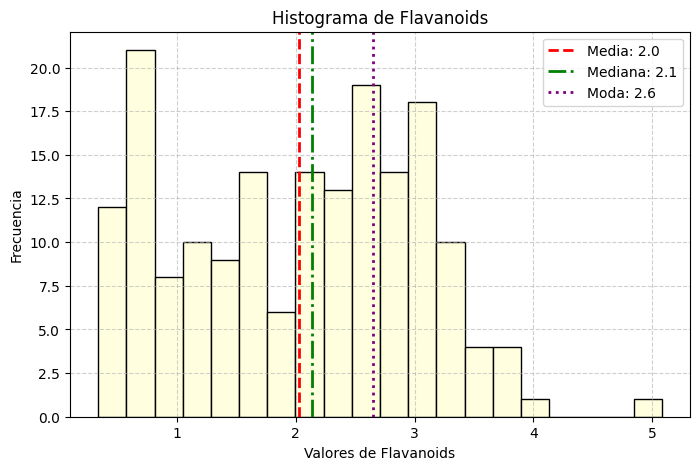

In [13]:
# Construye una función que, dado un dataframe y una cadena con el nombre de una variable, muestre un histograma de una variable predictora,
# y líneas de colores para representar la media, la mediana y la moda.Toma nota de las posibles asimetrías de las variables.
plt.style.use('default')  # estilo de los gráficos por defecto en matplolib

def histograma(df, variable):    

    x = df[variable] # asignamos 'variable' a x

    # Calcular medidas estadísticas básicas
    media = x.mean()             # Media: valor promedio
    mediana = x.median()         # Mediana: valor central
    moda = x.mode()[0]           # Moda: valor más frecuente
    asimetria = x.skew()         # Asimetría (skewness): mide la simetría de la distribución

    # Crear el histograma
    plt.figure(figsize=(8,5))    # Define el tamaño del gráfico
    plt.hist(x,  # variable a utulizar en el histograma
             bins=20,  # número de columnas a utilizar en el histograma (por defecto 10)
             color='lightyellow', # color de las columnas
             edgecolor='black' # color del borde de las columnas
            )  

    # Añadir líneas verticales con las medidas estadísticas
    plt.axvline(media, color='red', linestyle='--', linewidth=2, 
                label=f'Media: {media:.1f}')
    plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, 
                label=f'Mediana: {mediana:.1f}')
    plt.axvline(moda, color='purple', linestyle=':', linewidth=2, 
                label=f'Moda: {moda:.1f}')

    # Personalización del gráfico
    plt.title(f'Histograma de {variable}')
    plt.xlabel(f'Valores de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend()                                         # Muestra las líneas con etiquetas
    plt.grid(True, linestyle='--', alpha=0.6)            # Cuadrícula para facilitar la lectura

    plt.show()                                           # Muestra el gráfico final

histograma(df,'Flavanoids') # llamada a la función

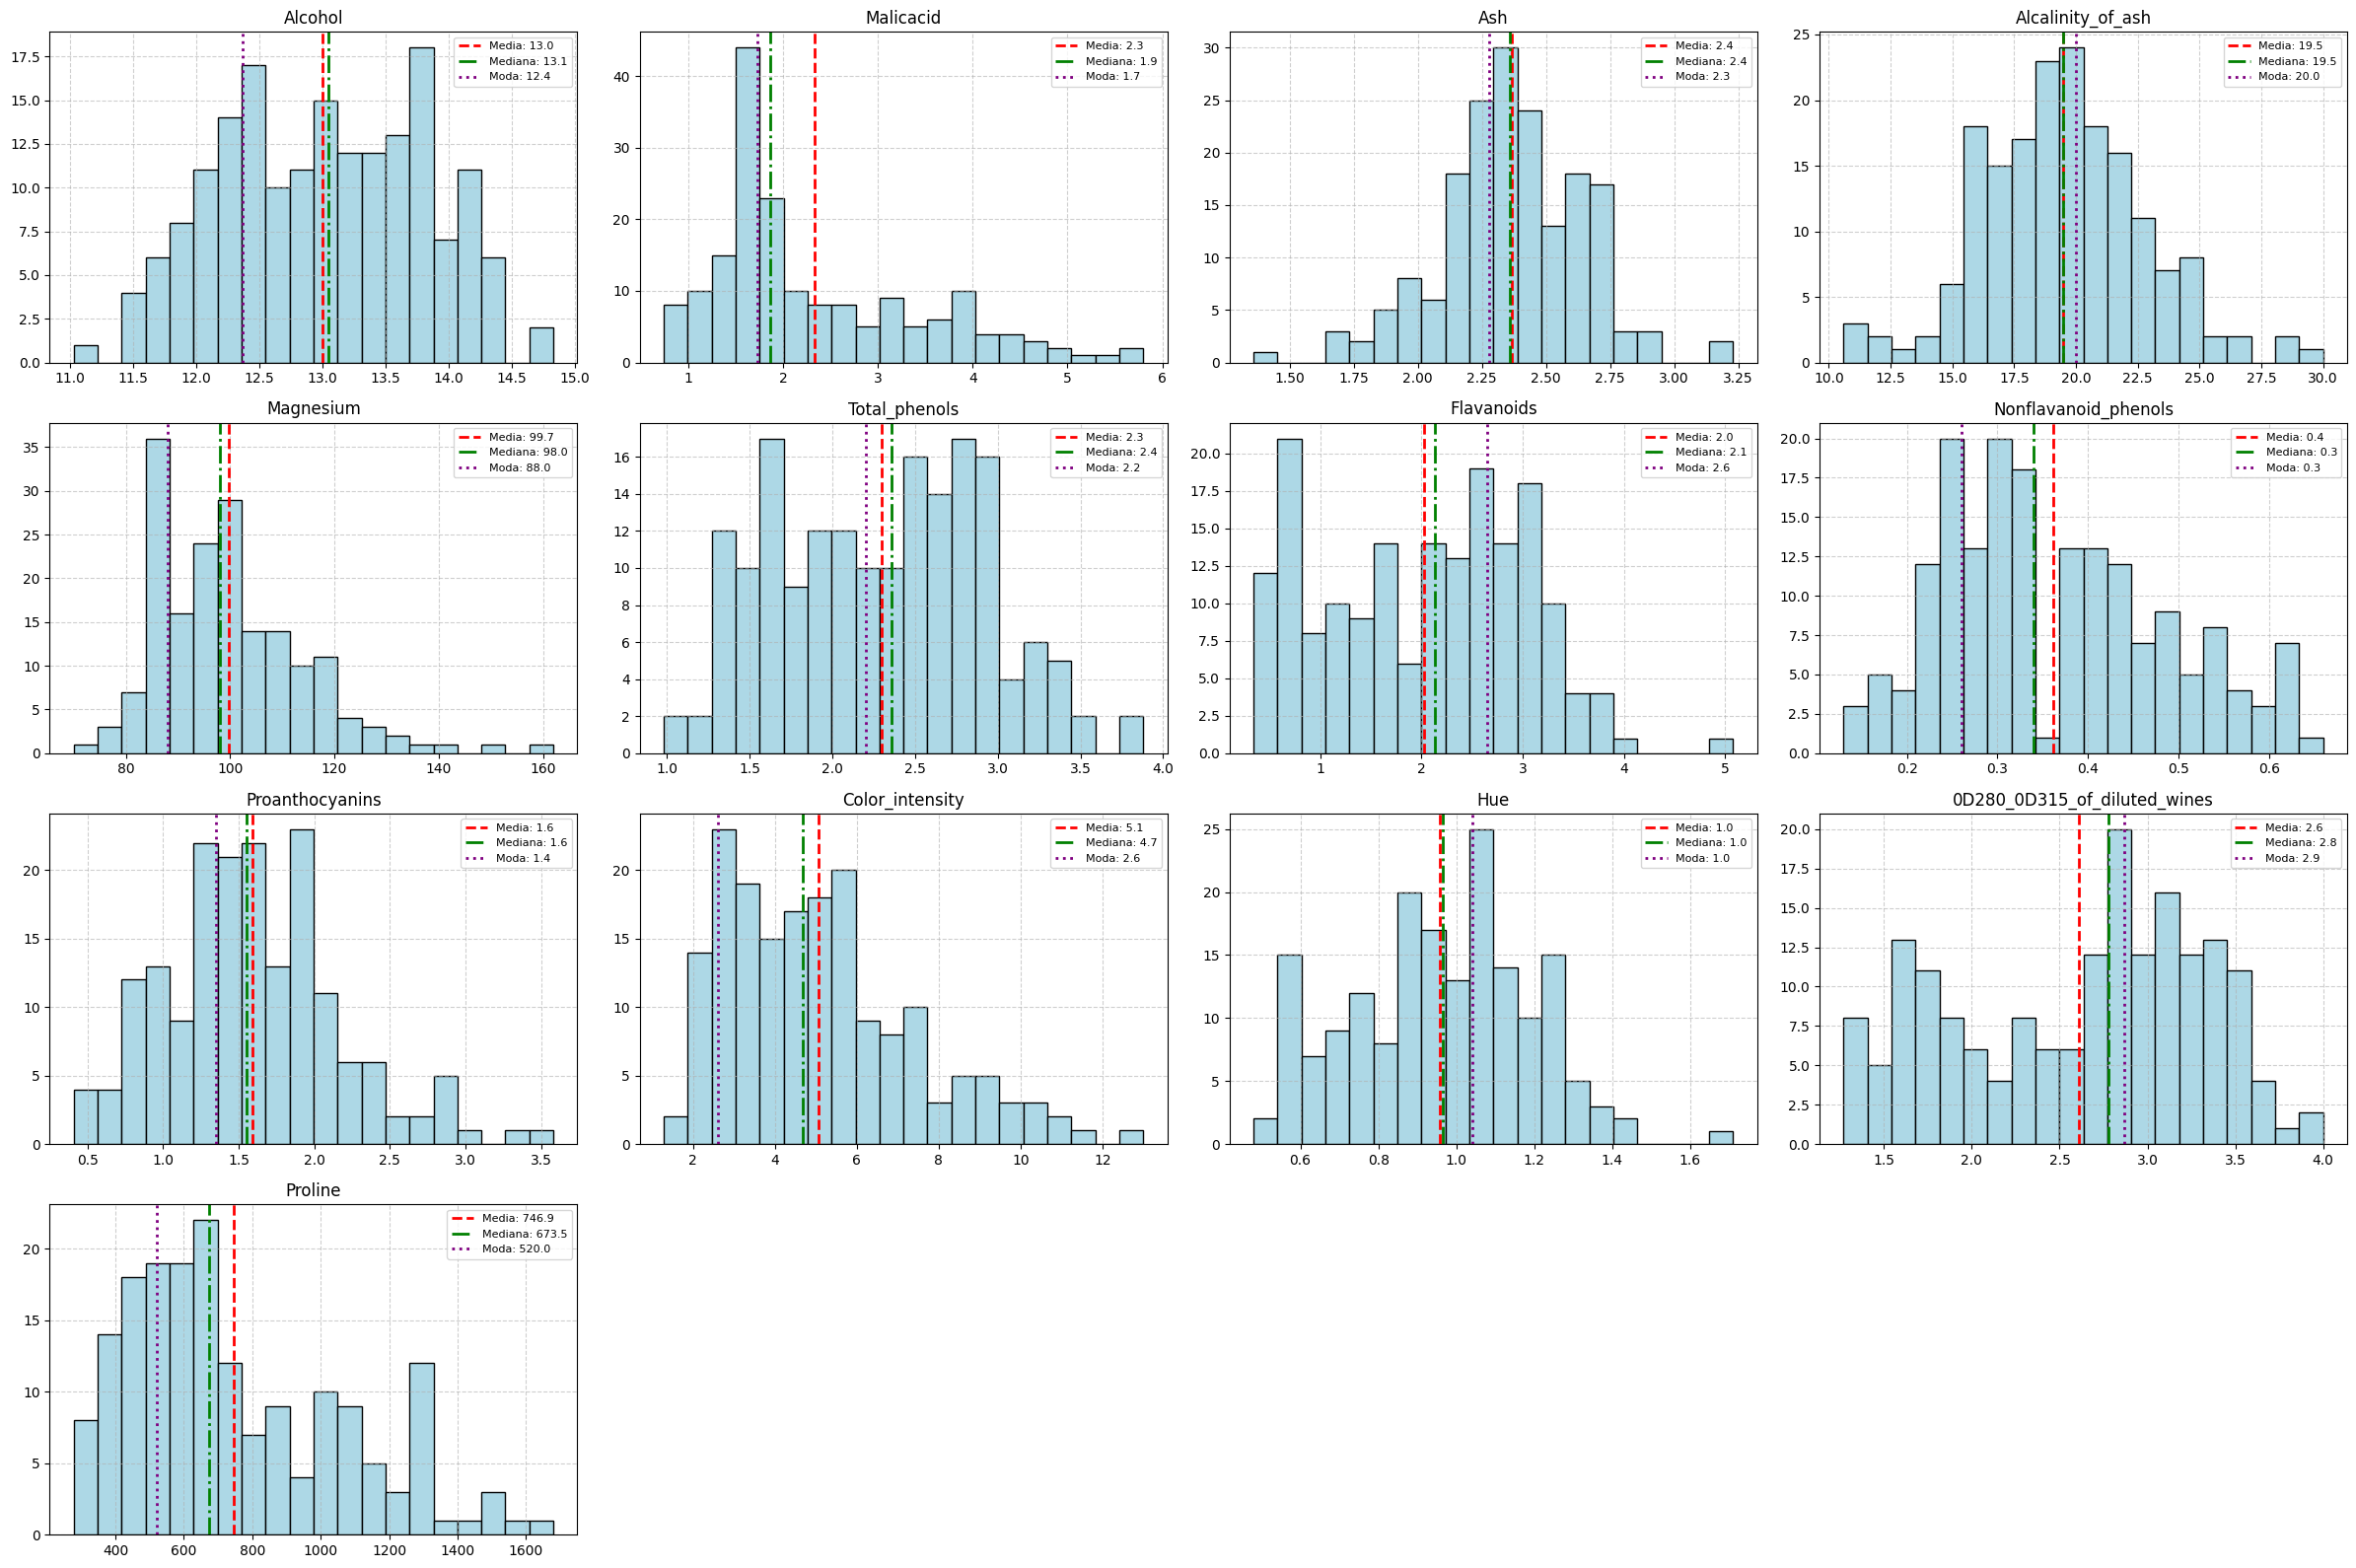

In [14]:
import matplotlib.pyplot as plt
import math


def histogramas(df, variables):
    """
    Crea una rejilla de histogramas con medidas estadísticas,  ajustando automáticamente el número de filas y columnas.
    """

    n_vars = len(variables) # número de variables a representar
    
    # Calcular número de filas y columnas automáticamente.
    # calcula el número de columnas para organizar n_vars elementos en una cuadrícula lo más cuadrada posible sin que falten huecos.
    # (puede sobrar alguno)
    columnas = math.ceil(math.sqrt(n_vars))  #raíz cuadrada del número de variables y redondeo hacia arriba al entero más cercano
    
    # calcula el número mínimo de filas necesarias para colocar todos los elementos cuando cada fila tiene un número fijo de columnas.
    filas = math.ceil(n_vars / columnas)  # En cuántas filas distribuyo el número de columnas anterior
   
    # Crear figura y rejilla de ejes
    # plt.subplots(filas, columnas, ...) crea varios gráficos (subplots) organizados en una rejilla de filas × columnas.
    # axes: un array de objetos Axes, cada uno de los cuales representa un subplot (un gráfico individual dentro de la figura).
   
    fig, axes = plt.subplots(filas, columnas,figsize=(6*columnas, 4*filas) )
    # Por defecto matplotlib usa 6×4 pulgadas, lo cual es suficiente para un solo gráfico pero, con varios subplots, hay que ajustar el tamaño.
    # 6 * columnas : el ancho total crece proporcionalmente al número de columnas.
    # 4 * filas : el alto total crece proporcionalmente al número de filas.
 
    axes = axes.flatten()  # convierte la matriz 2D de axes en una lista con columnas*filas elementos (un axe-eje) para iterar sobre ellos.

    for i, variable in enumerate(variables):
        ax = axes[i]
        x = df[variable].dropna()  # eliminar valores faltantes si no se han tratado previamente

        # Calcular medidas estadísticas
        media = x.mean()
        mediana = x.median()
        moda = x.mode()[0] # la distribución puede ser bimodal, trimodal, etc. Elegimos la primera moda

        # Dibujar histograma
        ax.hist(x, bins=20, color='lightblue', edgecolor='black')
        ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}') # línea vertical en la posición de la media
        ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.1f}') # línea vertical en la posición de la mediana
        ax.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}') # línea vertical en la posición de la moda

        ax.set_title(variable, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Apagar ejes sobrantes si los hay
    # i es el último índice usado en el bucle anterior donde se grafica cada variable.
    # axes es la lista (o array aplanado) con todos los subgráficos (conjunto de ejes) creados por plt.subplots.
    # len(axes) es el número total de subplots. por lo tanto, el siguiente for recorre todos los ejes que no se usaron,
    # es decir, desde el siguiente (i+1) hasta el final de la lista.
    for j in range(i+1, len(axes)):
        axes[j].axis('off') # apagamos el j-ésimo eje
    
    # plt.tight_layout() ajusta automáticamente los espacios y márgenes entre subplots
    # para que los textos (títulos, ejes, leyendas) no se superpongan ni queden cortados.
    plt.tight_layout()
    plt.show()

histogramas(df,predictoras)

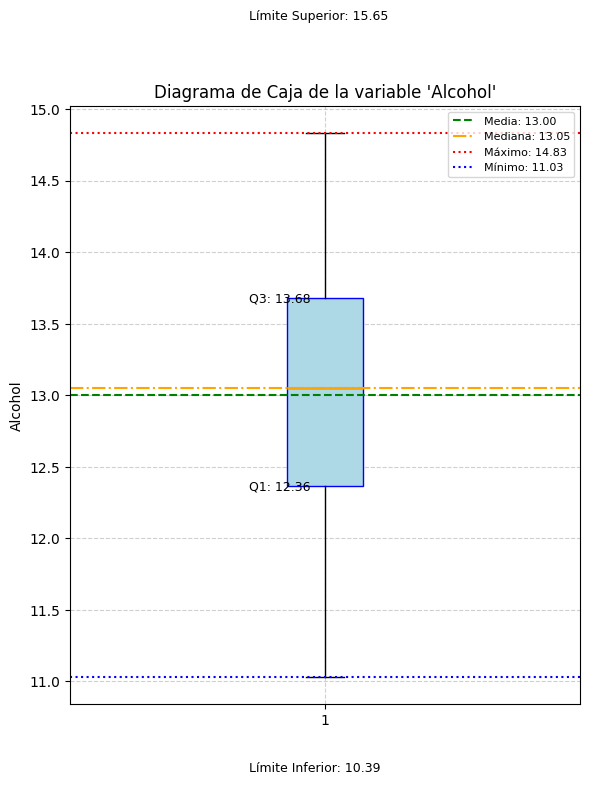

{'Q1': np.float64(12.362499999999999),
 'Q3': np.float64(13.6775),
 'median': np.float64(13.05),
 'mean': np.float64(13.00061797752809),
 'min': np.float64(11.03),
 'max': np.float64(14.83),
 'IQR': np.float64(1.3150000000000013),
 'lim_inf': np.float64(10.389999999999997),
 'lim_sup': np.float64(15.650000000000002)}

In [15]:
def boxplot_variable(df, var):
    """
    Representa un diagrama de caja (boxplot) para una variable numérica y calcula sus principales estadísticas descriptivas.

    Parámetros
    ----------
    df : pandas.DataFrame        #Conjunto de datos.
    var : str                    #Nombre de la columna numérica a analizar.
    Retorna
    -------
    stats : dict                 #Diccionario con las estadísticas calculadas.
    """ 
    # Dibujo del boxplot
    plt.figure(figsize=(6, 8))
    plt.boxplot(df[var].dropna(),
                vert=True,
                patch_artist=True, # permite colorear la caja (por defecto es transparente).
                boxprops=dict(facecolor="lightblue", color="blue"), # color de la caja y su borde.
                medianprops=dict(color="orange", linewidth=2)) # color y grosor de la línea de la mediana
    
    plt.title(f"Diagrama de Caja de la variable '{var}'")
    plt.ylabel(var)

    # Cálculo de estadísticas
    stats = {}
    stats['Q1'] = df[var].quantile(0.25)
    stats['Q3'] = df[var].quantile(0.75)
    stats['median'] = df[var].median()
    stats['mean'] = df[var].mean()
    stats['min'] = df[var].min()
    stats['max'] = df[var].max()
    stats['IQR'] = stats['Q3'] - stats['Q1']
    stats['lim_inf'] = stats['Q1'] - 1.5 * stats['IQR']
    stats['lim_sup'] = stats['Q3'] + 1.5 * stats['IQR']

    # Líneas horizontales para los principales valores
    lineas = {
        'Media': ('mean', 'green', '--'),
        'Mediana': ('median', 'orange', '-.'),
        'Máximo': ('max', 'red', ':'),
        'Mínimo': ('min', 'blue', ':')
    }

    for etiqueta, (clave, color, estilo) in lineas.items():
        plt.axhline(y=stats[clave], color=color, linestyle=estilo,
                    label=f"{etiqueta}: {stats[clave]:.2f}")

    # Textos con valores de cuartiles y límites
    textos = {
        'Q1': stats['Q1'],
        'Q3': stats['Q3'],
        'Límite Inferior': stats['lim_inf'],
        'Límite Superior': stats['lim_sup']
    }

    for etiqueta, valor in textos.items():
        plt.text(0.85, valor, f"{etiqueta}: {valor:.2f}",
                 color='black', fontsize=9, va='center')

    # Ajustes finales
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Retornar diccionario con estadísticas (opcional)
    return stats

boxplot_variable(df, 'Alcohol')


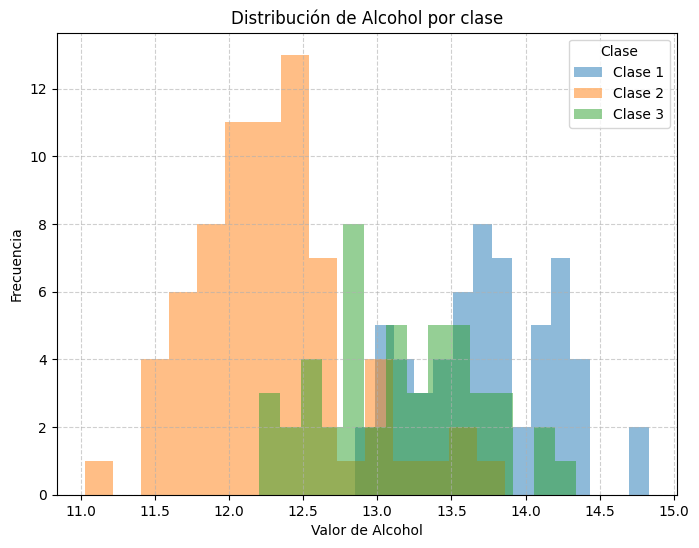

In [16]:
#
# 9. Gráficos y análisis de distribución de variables por clase. Histogramas.
# a. Construye una función que, dado un dataframe, una cadena con el nombre de una variable predictora y una cadena con la variable objetivo
#    muestre el histograma de la variable predictora para cada valor de clase.

def histograma_clase(df, variable, target='class'):
    
    plt.figure(figsize=(8, 6))   # tamañao de la figura. Por defecto son (6 pulg x 6 pulg)
    clases = df[target].unique() # lista valores únicos de la variable a predecir

    # Recorre todas las clases; i es el índice (0, 1, 2, …) y c es el valor de la clase (por ejemplo, 0 o 1).
    for i, c in enumerate(clases): # i índice de la lista clases. c valores de la lista 
        # Filtra el DataFrame df para quedarse solo con las filas de la clase c y selecciona 'plas'
        mascara = df[target] == c # en cada iteración, asigna 'True' a las filas que satisfacen que 'class' == c. 'False' en caso  contrario
        x = df[mascara][variable] # para las filas anteriores, obtenemos el valor de 'variable'

        # dibujamos el histograma de la variable x
        plt.hist(x,                     # variable de la que queremos representar el histograma
                 bins=15,               # número de columnas del histograma
                 alpha=0.5,             # valor de transparencia-opacidad (1: no transparente. 0: invisible)
                 label=f'Clase {c}'     # etiqueta de clase
                )

    plt.title(f'Distribución de {variable} por clase')
    plt.xlabel(f'Valor de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend(title='Clase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


histograma_clase(df, 'Alcohol')

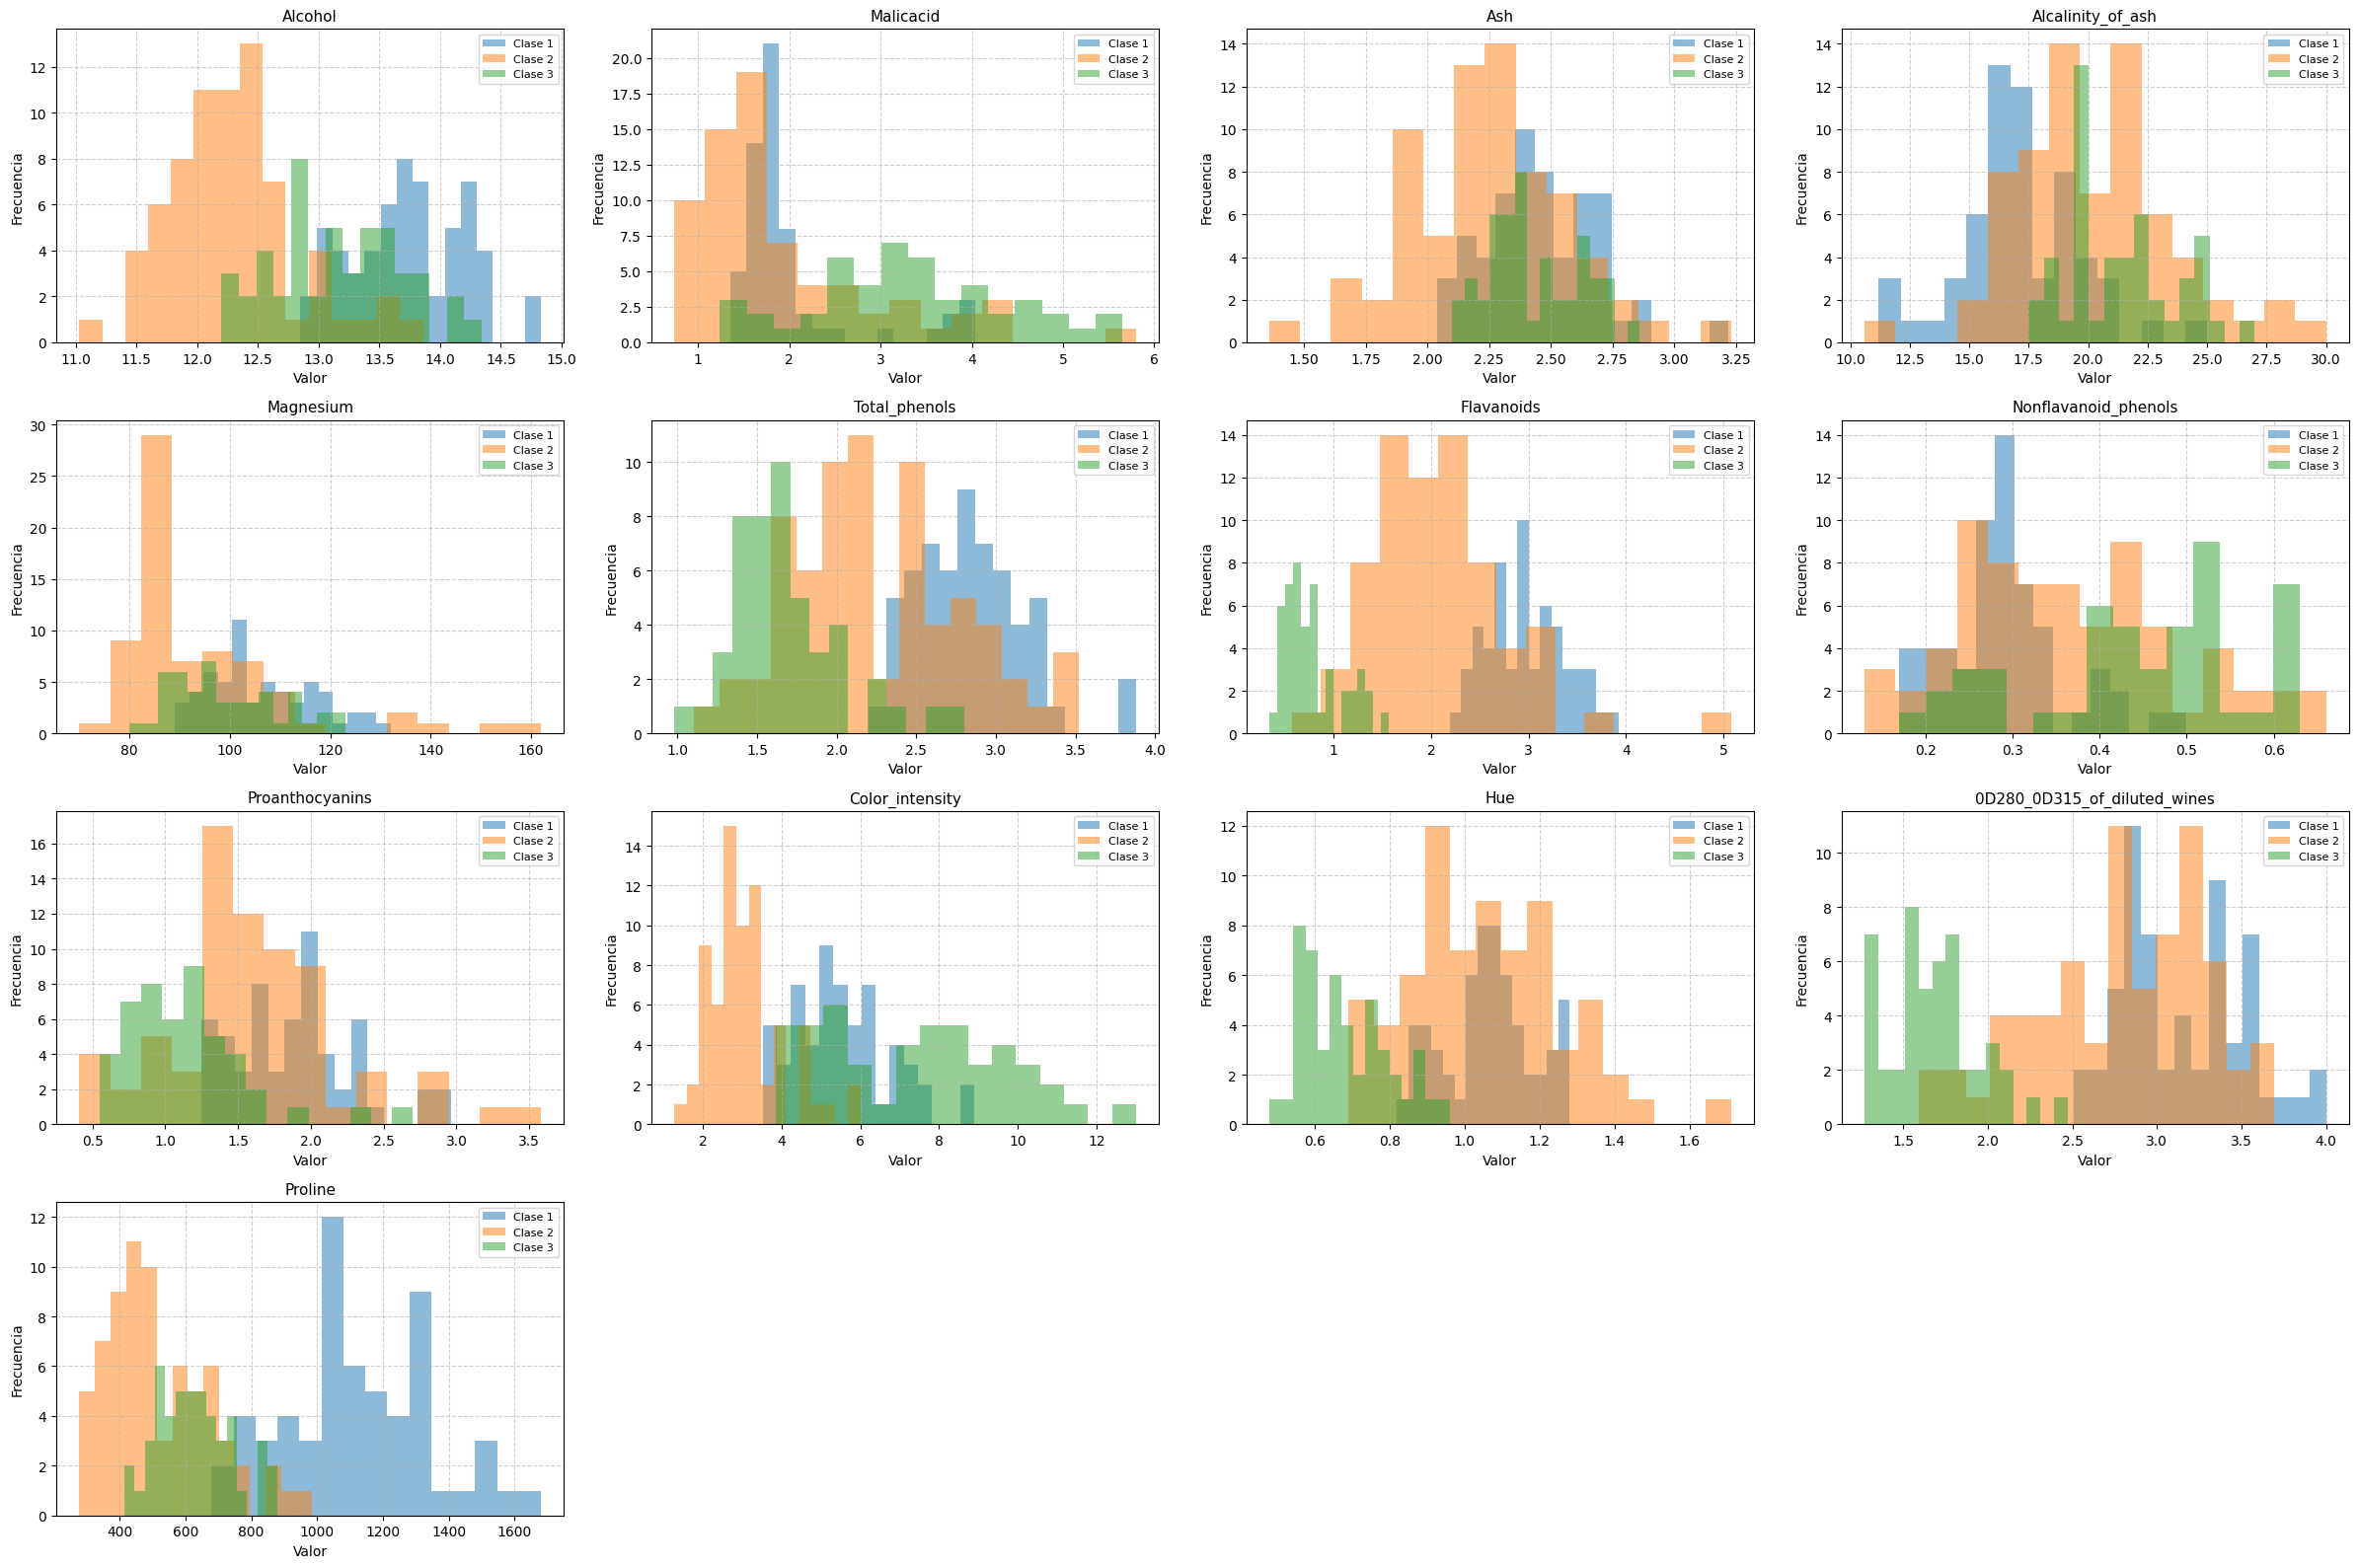

In [17]:
import matplotlib.pyplot as plt
import math

def histogramas_clase(df, variables, target='class'):
    """
    Crea una rejilla de histogramas para comparar la distribución de varias variables
    según las clases del target (por ejemplo, benigno/maligno).
    """

    # Número total de variables a graficar
    n_vars = len(variables)

    # Calcular automáticamente el número de columnas (aprox. raíz cuadrada)
    columnas = math.ceil(math.sqrt(n_vars))

    # Calcular el número de filas necesarias
    filas = math.ceil(n_vars / columnas)

    # Crear la figura y la rejilla de ejes (subplots)
    fig, axes = plt.subplots(filas, columnas, figsize=(6*columnas, 4*filas))

    # Aplanar la matriz de ejes (para recorrerla con un solo índice)
    axes = axes.flatten()

    # Obtener las clases únicas del target (por ejemplo, 0 y 1)
    clases = df[target].unique()

    # Recorrer cada variable a graficar
    for i, variable in enumerate(variables):
        ax = axes[i]  # Seleccionar el eje correspondiente

        # Dibujar un histograma para cada clase
        for c in clases:
            # Filtrar el dataframe por clase y seleccionar la variable actual
            mascara = df[target] == c # en cada iteración, asigna 'True' a las filas que satisfacen que 'class' == c. 'False' en caso  contrario
            x = df[mascara][variable]
            # Dibujar histograma de la variable x de esa clase
            ax.hist(x, bins=15, alpha=0.5, label=f'Clase {c}')

        # Personalizar el gráfico individual
        ax.set_title(f'{variable}', fontsize=11)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Apagar los ejes vacíos si sobran
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Ajustar márgenes y espacio entre gráficos
    plt.tight_layout()

    # Mostrar toda la figura
    plt.show()

histogramas_clase(df, predictoras)
# Con base a las gráficas siguientes, ¿qué conclusiones puedes extraer?



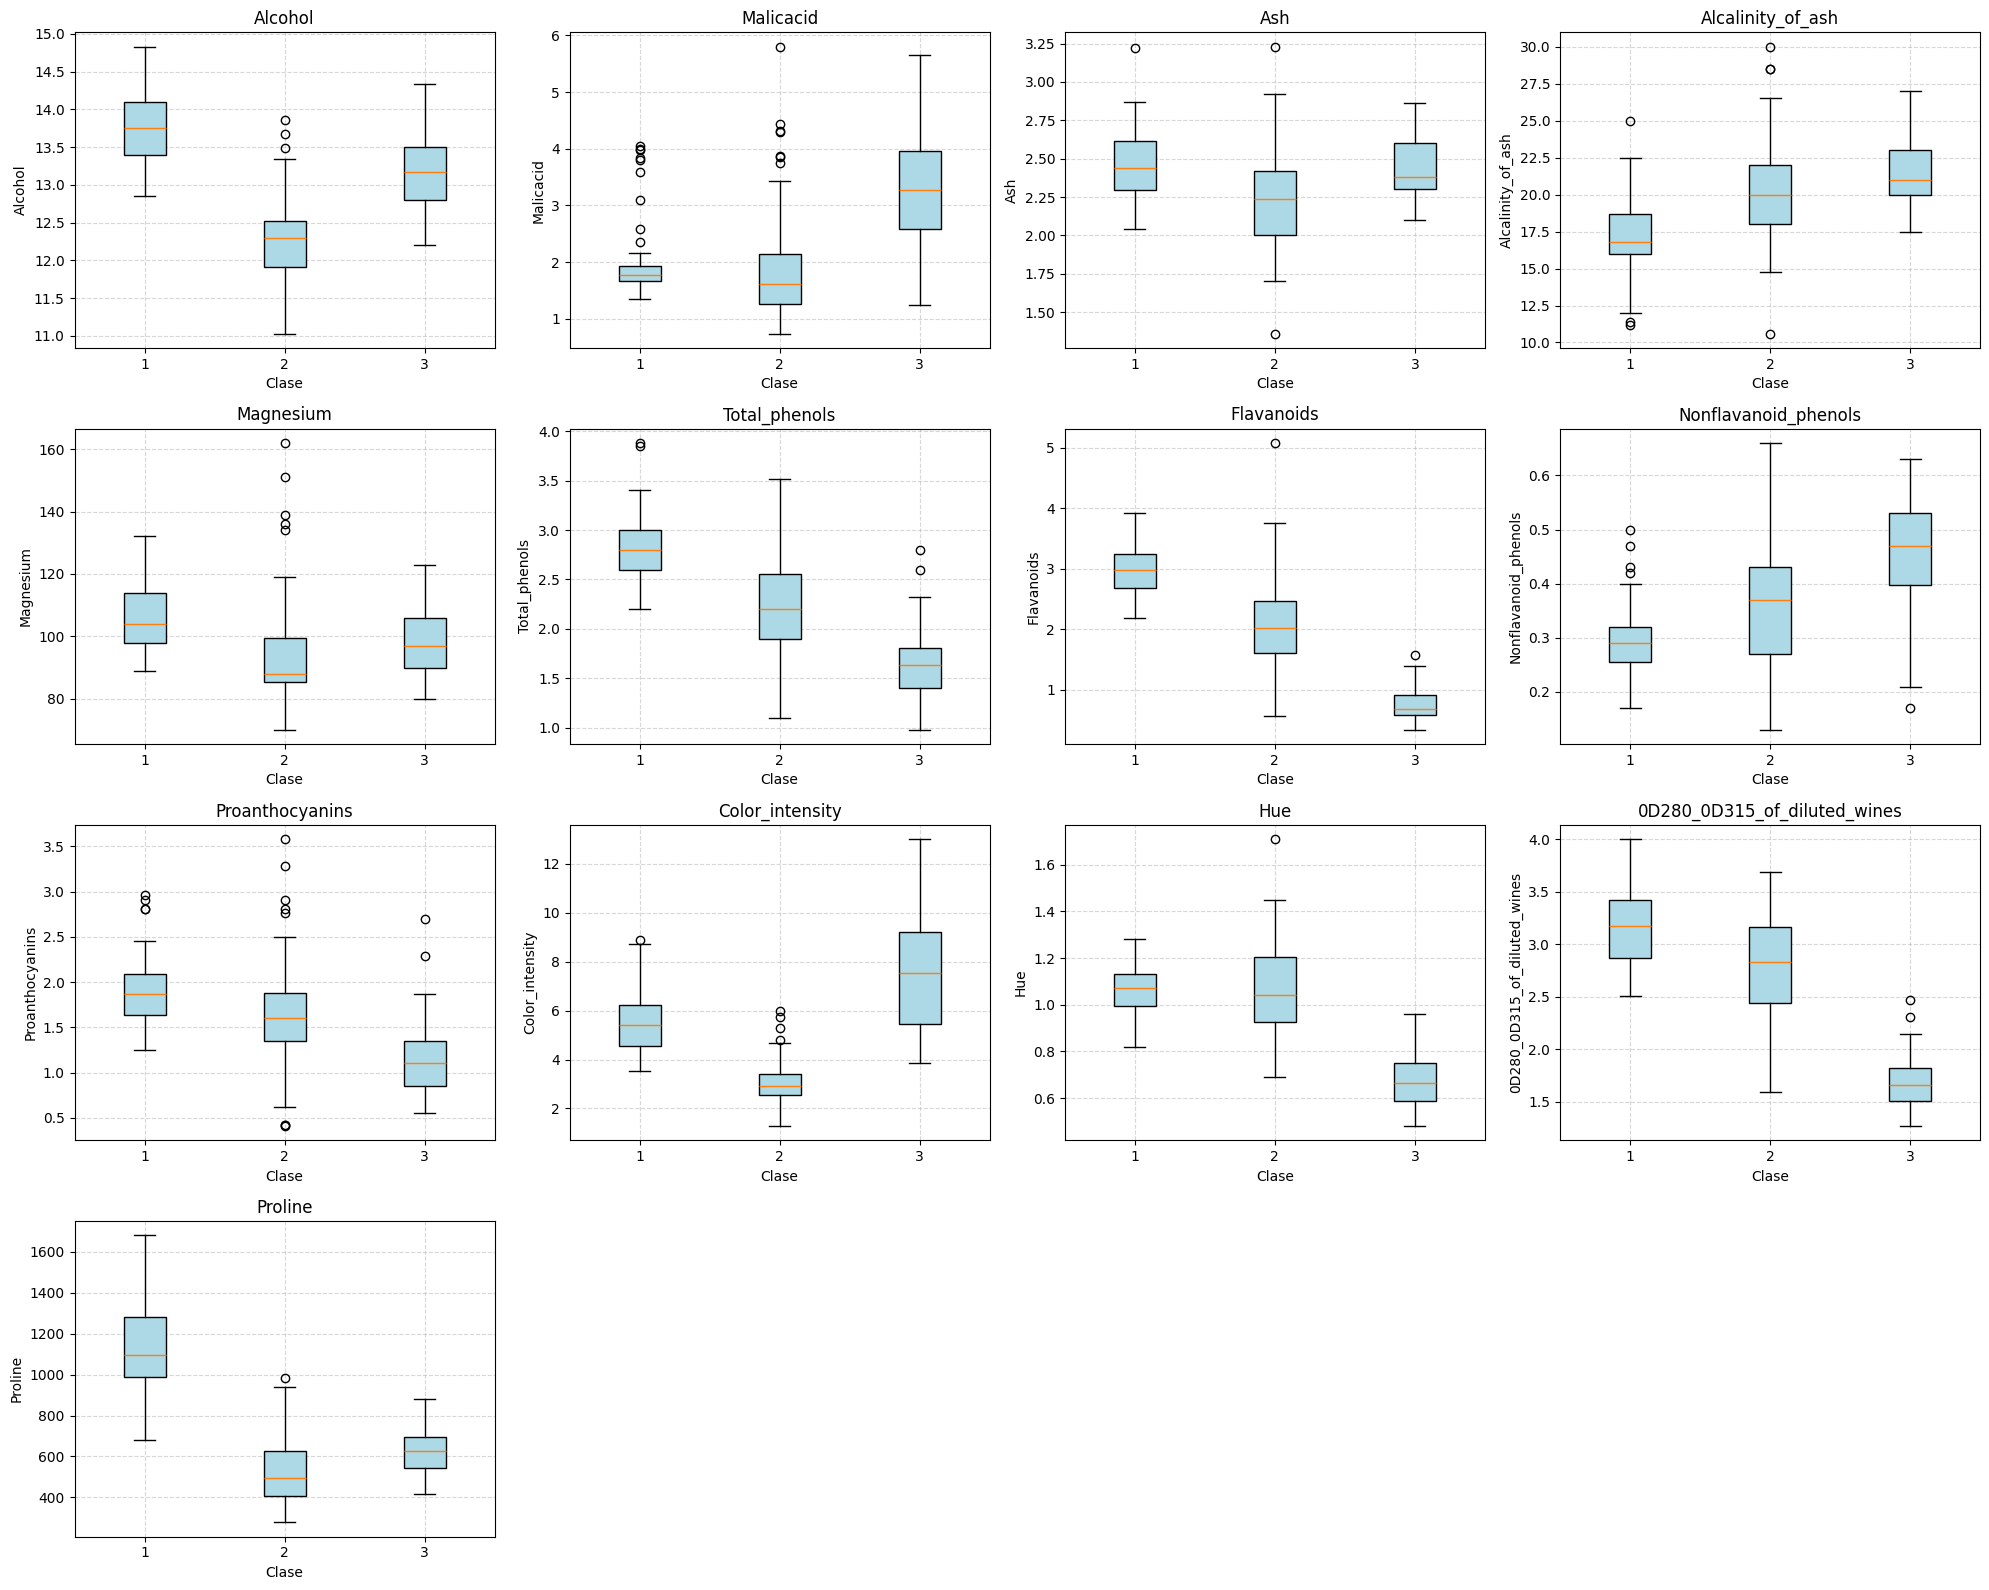

In [18]:
import matplotlib.pyplot as plt
import math

def boxplots_clase(df, variables, target='class'):
    """
    Dibuja, en una rejilla de subplots, boxplots de varias variables numéricas diferenciadas por clase (columna 'target').
    
    Parámetros
    ----------
    df : pandas.DataFrame        #DataFrame con los datos.
    variables : list             #Lista de nombres de columnas numéricas a representar.
    target : str                 #Nombre de la columna de clase (por defecto 'target').
    """

    clases = df[target].unique()  # valores únicos de clase
    num_variables = len(variables)  # número de variables

    # Calcular número de filas y columnas automáticamente (rejilla casi cuadrada)
    columnas = math.ceil(math.sqrt(num_variables))
    filas = math.ceil(num_variables / columnas)

    # Crear figura y ejes
    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 4*filas))
    axes = axes.flatten()  # lista 1D de ejes, para recorrela con un sólo índice

    for i, variable in enumerate(variables): #i: índice y valor de la lista de variables 
        ax = axes[i]                         # en cada iteración, ax es un conjunto de ejes para dibujar cada variable 

        # Lista de valores de la variable 'variable' para cada clase c en la lista de clases
        x = [df[df[target] == c][variable].dropna() for c in clases]

        # Boxplot por clase
        ax.boxplot(
            x,
            tick_labels=clases,                  # # Etiquetas con el nombre de la clase, en el eje X
            patch_artist=True,                   # Rellenar las cajas
            boxprops=dict(facecolor='lightblue') # Color de las cajas
        )

        ax.set_title(variable)
        ax.set_xlabel('Clase')
        ax.set_ylabel(variable)
        ax.grid(True, linestyle='--', alpha=0.5)

    # Apagar ejes sobrantes (si la rejilla de tamaño columasxfilas es más grande que el nº de variables 'num_variables')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


 

boxplots_clase(df, predictoras)


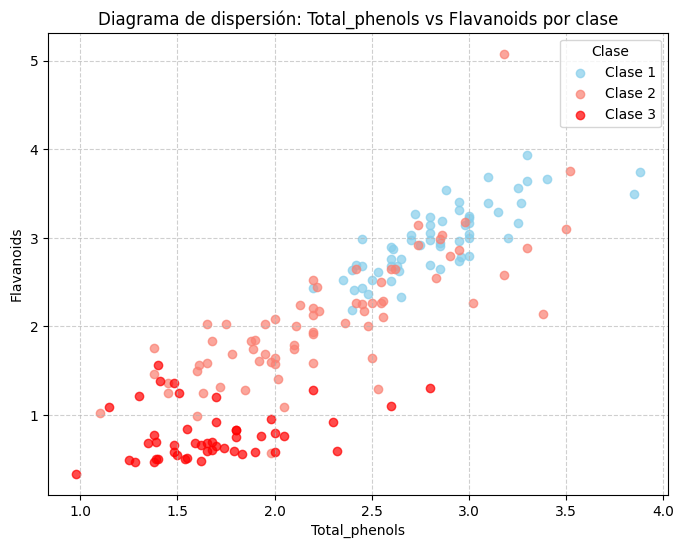

In [19]:
#
# 10. Gráficos y análisis de distribución de variables por clase. Scatter.
# a. Construye una función que, dado un dataframe, dos cadenas con dos nombres de dos variables predictoras y una cadena con la variable objetivo
#    muestre el scatter de las dos variables predictoras discriminadas por clase para cada valor de clase.

import matplotlib.pyplot as plt

def scatter_clase(df, variable1, variable2, target='class'):
    plt.figure(figsize=(8, 6))
    
    # Clase 1
    plt.scatter(df[df[target] == 1][variable1], # una serie -columna de datos con índice- de valores columna 'variable1' de df
            df[df[target] == 1][variable2],     # una serie -columna de datos con índice- de valores columna 'variable2' de df
            color='skyblue',
            alpha=0.7,
            label='Clase 1')

    # Clase 2
    plt.scatter(df[df[target] == 2][variable1],
            df[df[target] == 2][variable2],
            color='salmon',
            alpha=0.7,
            label='Clase 2')
    
    # Clase 3
    plt.scatter(df[df[target] == 3][variable1],
            df[df[target] == 3][variable2],
            color='red',
            alpha=0.7,
            label='Clase 3')

    plt.title(f'Diagrama de dispersión: {variable1} vs {variable2} por clase')
    plt.xlabel(f'{variable1}')
    plt.ylabel(f'{variable2}')
    plt.legend(title='Clase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

scatter_clase(df, 'Total_phenols', 'Flavanoids')




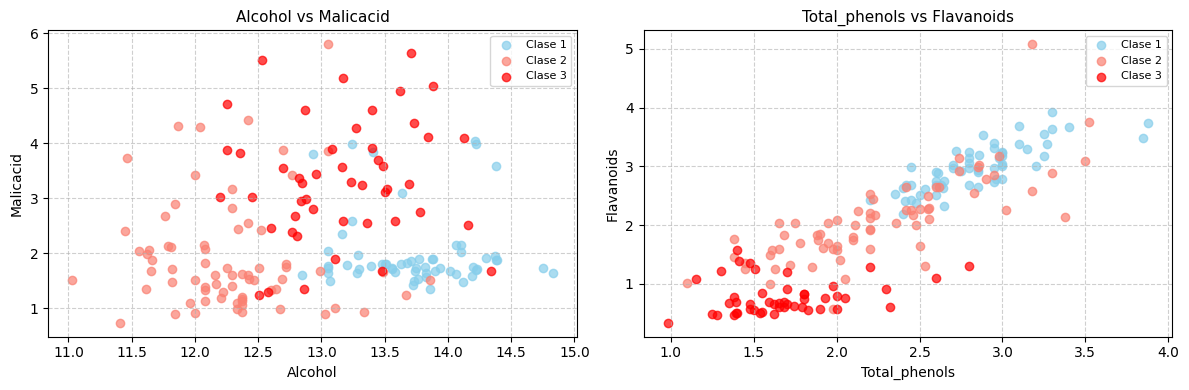

In [20]:
# b. Utilizando esta función, muestra  -mediante un bucle for- todos los scatters por clase, correspondientes a las variables predictoras.

import matplotlib.pyplot as plt
import math

pares = [('Alcohol', 'Malicacid'), ('Total_phenols', 'Flavanoids')]

def scatter_clases(df, pares, target='class'):
    """
    Dibuja varios diagramas de dispersión (scatter plots) por clase para diferentes pares de variables, organizados automáticamente
    en una rejilla de subplots.
    
    Parámetros
    ----------
    df : pandas.DataFrame   #Conjunto de datos.
    pares : list of tuple   #Lista de tuplas con pares de variables
    target : str            #Nombre de la columna de clase (por defecto 'class').
    """

    n_pares = len(pares)  # Número total de gráficos a dibujar

    # Calcular el número de columnas (aprox. cuadrado)
    columnas = math.ceil(math.sqrt(n_pares))

    # Calcular el número de filas necesarias
    filas = math.ceil(n_pares / columnas)

    # Crear la figura y la rejilla de ejes (subplots)
    fig, axes = plt.subplots(filas, columnas, figsize=(6*columnas, 4*filas))

    # Convertir axes en lista 1D para iterar fácilmente sobre ellos
    axes = axes.flatten()

    # Recorrer los pares de variables
    for i, (var1, var2) in enumerate(pares):
        ax = axes[i]  # seleccionar el eje correspondiente

        # Dibujar los puntos de la clase 1 (malignos)
        ax.scatter(df[df[target] == 1][var1],
                   df[df[target] == 1][var2],
                   color='skyblue', alpha=0.7, label='Clase 1')

        # Dibujar los puntos de la clase 2 (benignos)
        ax.scatter(df[df[target] == 2][var1],
                   df[df[target] == 2][var2],
                   color='salmon', alpha=0.7, label='Clase 2')

        # Dibujar los puntos de la clase 3 (benignos)
        ax.scatter(df[df[target] == 3][var1],
                   df[df[target] == 3][var2],
                   color='red', alpha=0.7, label='Clase 3')


        # Personalización del gráfico individual
        ax.set_title(f'{var1} vs {var2}', fontsize=11)
        ax.set_xlabel(var1)
        ax.set_ylabel(var2)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=8)

    # Apagar ejes sobrantes si hay más espacios que gráficos
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Ajustar márgenes y mostrar
    plt.tight_layout()
    plt.show()

scatter_clases(df, pares)


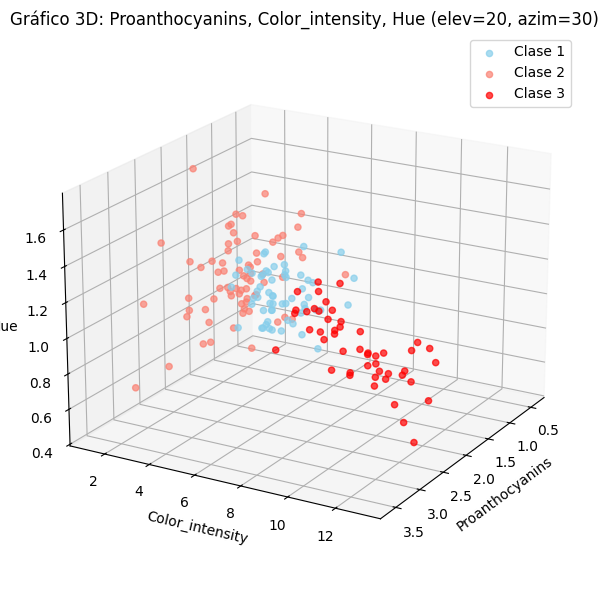

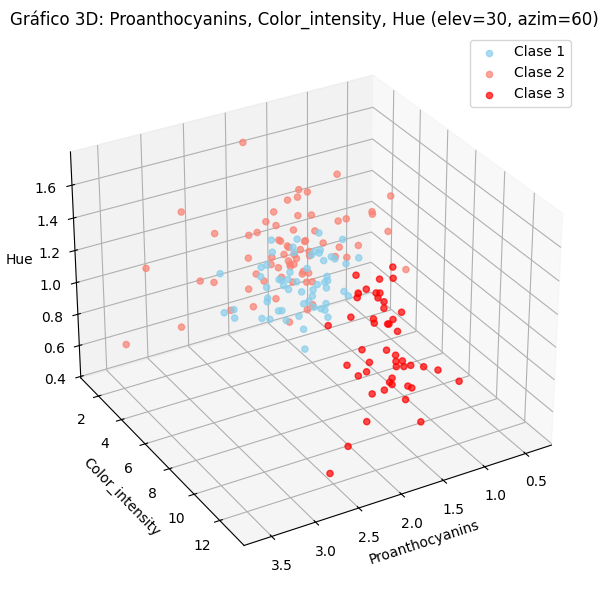

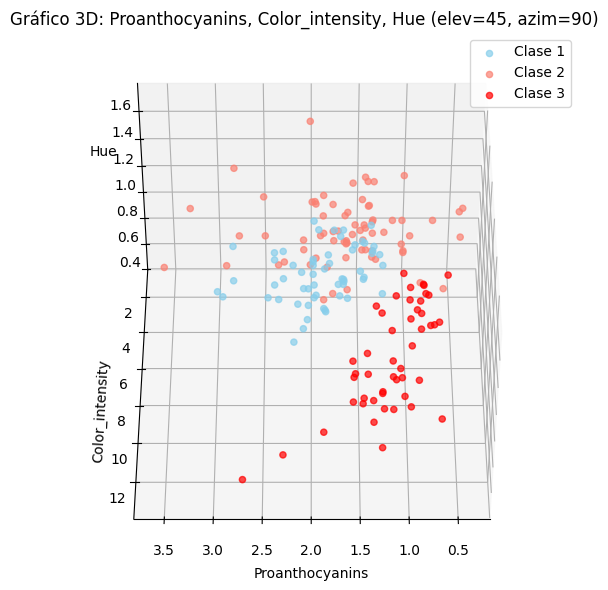

NameError: name 'x' is not defined

In [21]:
#
#  Gráfico 3D
# a. Elige tres variables predictoras originales, represéntalas desde diferentes ángulos (5 combinaciones de azimut y altura).
# Haz esta representación mediante el uso iterativo de una función que acepte un dataframe, tres cadenas de caracteres
# cada una de las cuales contenga el nombre de una variable predictora, un valor de azimut y un valor de altura.
# b. En base a la visualización anterior, extrae las conclusiones pertinentes.


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def grafico_3d(df, x_var, y_var, z_var, elev, azim):
    """
    Dibuja un gráfico 3D de tres variables numéricas con una orientación definida.
    Parámetros:
    df    : DataFrame con los datos
    x_var : nombre de la variable para el eje X
    y_var : nombre de la variable para el eje Y
    z_var : nombre de la variable para el eje Z
    elev  : ángulo de elevación de la cámara
    azim  : ángulo de rotación (azimut)
    """
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection='3d')
    plt.title(f'Gráfico 3D: {x_var}, {y_var}, {z_var} (elev={elev}, azim={azim})')
    # Clase 1
    x0 = df[df['class'] == 1][x_var]
    y0 = df[df['class'] == 1][y_var]
    z0 = df[df['class'] == 1][z_var]
    ax.scatter3D(x0, y0, z0, color='skyblue', alpha=0.7, label='Clase 1')
    # Clase 2
    x1 = df[df['class'] == 2][x_var]
    y1 = df[df['class'] == 2][y_var]
    z1 = df[df['class'] == 2][z_var]
    ax.scatter3D(x1, y1, z1, color='salmon', alpha=0.7, label='Clase 2')
    # Clase 3
    x1 = df[df['class'] == 3][x_var]
    y1 = df[df['class'] == 3][y_var]
    z1 = df[df['class'] == 3][z_var]
    ax.scatter3D(x1, y1, z1, color='red', alpha=0.7, label='Clase 3')

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.legend()
    # Cambiar orientación
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


var1, var2 , var3 = ('Proanthocyanins', 'Color_intensity', 'Hue')


# Gráfico 1
grafico_3d(df, var1, var2, var3, elev=20, azim=30)

# Gráfico 2
grafico_3d(df, var1, var2, var3, elev=30, azim=60)

# Gráfico 3
grafico_3d(df, var1, var2, var3 , elev=45, azim=90)

# Gráfico 4
grafico_3d(df, x, y_, z, elev=60, azim=120)

# Gráfico 5
grafico_3d(df, x, y_, z, elev=15, azim=180)

# Gráfico 6
grafico_3d(df, x, y_, z, elev=30, azim=270)



In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x='Proline', y='Flavanoids', z='Alcohol',
              color='class')
fig.show()

In [ ]:
X

In [22]:
# estandarizamos las variables predictoras. Recordamos que están en el objeto X, un dataframe de Pandas.
# la estandarización se realiza para que todas las variables estén en una escala comparable y el algoritmo las tenga en cuenta a todas.

from sklearn.preprocessing import StandardScaler # importamos las librerías necesarias

scaler = StandardScaler() # instanciamos un objeto StandardScaler()
X_scaled = scaler.fit_transform(X) # entrenamiento y transformación de las variables del dataframe X a variables con media 0 y desv. típica 1 



In [23]:
# Verificamos que la estandarización se ha llevado a cabo exitosamente.
# Nota X_scaled es un array de numpy -no es un dataframe de Pandas
print(type(X_scaled))
X_scaled

<class 'numpy.ndarray'>


array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [24]:
from sklearn.cluster import KMeans
# Importa la clase KMeans de scikit-learn, que implementa el algoritmo K-means

km = KMeans(
    n_clusters=3,      # Número de clusters (K). El algoritmo intentará agrupar los datos en 3 grupos distintos.

    init='k-means++',  # Inicialización centroides. 'k-means++' elige centroides iniciales de forma  que celera convergencia y mejora resultados.

    n_init='auto',     # Número de veces que el algoritmo se ejecuta con distintas inicializaciones de centroides.
                       # Se conserva el resultado con la menor suma de distancias internas (inercia). Es decir, el algoritmo se lanza n_init veces
                       # cada vez con centroides iniciales diferentes, se queda con la mejor ejecución: la que tenga menor inercia (inertia_)

    max_iter=300,      # Número máximo de iteraciones permitidas en cada ejecución. Evita bucles infinitos si el algoritmo no converge rápidamente.

    tol=0.0001,        # Tolerancia. Si el cambio en la posición de los centroides entre iteraciones es menor que este valor, el algoritmo se detiene.

    random_state=10,   # Semilla del generador de números aleatorios. Garantiza que los resultados sean reproducibles.

    algorithm='elkan'  # Algoritmo interno usado para calcular K-means. Acelera el cálculo de distancias y la asignación de puntos a centroides.
    
)


In [25]:
# km.fit(X_scaled)

# 1. Inicializa 𝑘 centroides (aleatoriamente o con k-means++)
# 2. Repite hasta converger:
#      asigna cada punto al centroide más cercano
#      recalcula los centroides como la media de los puntos asignados
# 3. Guarda el resultado dentro del objeto km

km.fit(X_scaled)

#Después del fit, el modelo ya tiene la siguiente información:
    # km.cluster_centers_ : coordenadas de los centroides
    # km.labels_          : etiqueta (cluster) asignada a cada punto
    # km.inertia_         : suma de distancias internas (medida de cuán compacto es cada clúster)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,10
,copy_x,True
,algorithm,'elkan'


In [146]:
print(f'Número de clústeres: {km.cluster_centers_.shape[0]}')
print(f'\nNúmero coordenadas de cada centro de un clúster: {km.cluster_centers_.shape[1]}')
print(f'\nCoordenadas de los centroides de los clusters: {km.cluster_centers_}')

Número de clústeres: 3

Número coordenadas de cada centro de un clúster: 13

Coordenadas de los centroides de los clusters: [[ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]
 [-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]]


In [147]:
# Suma de las distancias cuadradas de cada punto a su centroide más cercano.
print('Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide): ',km.inertia_)

Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide):  1277.928488844642


In [148]:
print('Número de iteraciones: ',km.n_iter_)

Número de iteraciones:  8


In [149]:
print(f'Etiquetas de clúster asignadas por k-means a cada instancia de X:\n {km.labels_}')

Etiquetas de clúster asignadas por k-means a cada instancia de X:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 2 2 1 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [150]:
len(km.labels_)

178

In [151]:
y

,class
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


## Inercia en K-means

La **inercia** es la **suma de las distancias cuadradas** de cada punto a su **centroide** (el centro del cluster al que pertenece):

$$
\displaystyle
\text{Inercia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \left\| x_i - \mu_k \right\|^2
$$

Donde:

- $K$: número de clusters  
- $C_k$: conjunto de puntos del cluster $k$  
- $\mu_k$: centroide del cluster $k$



In [26]:
inercias = [] # lista vacía dónde iremos colocando valores de inercia
n_clusters = range(1,11) # evaluaremos la inercia para 1 clúster, 2 clústeres, 3 clústeres,...., 10 clústeres
for n in n_clusters:
    print(f'Evaluando {n} clústeres')
    km = KMeans(n_clusters=n,  # instancia mos un objeto k-means para n clústeres
           init='k-means++',   # método de asignación de centroides. Pueden asignarse aleatoriamente por este método 'k-means++'
           n_init='auto',      # Número de veces que el algoritmo se ejecuta con distintas inicializaciones de centroides.
           max_iter=300,       # Número máximo de iteraciones en cada ejecución. Evita bucles infinitos si el algoritmo no converge rápidamente.
           tol=0.0001,         # Cambio en la posición de los centroides entre iteraciones es menor que este valor, el algoritmo se detiene.
           random_state=10,    # reproductibilidad
           algorithm='lloyd'   # algoritmo cálculo de distancias y la asignación de puntos a centroides.
           )
    km.fit(X_scaled)           # Entrenamiento del algoritmo
    inercias.append(km.inertia_)  #lista que contiene la inercia calculada para cada n

Evaluando 1 clústeres
Evaluando 2 clústeres
Evaluando 3 clústeres
Evaluando 4 clústeres
Evaluando 5 clústeres
Evaluando 6 clústeres
Evaluando 7 clústeres
Evaluando 8 clústeres
Evaluando 9 clústeres
Evaluando 10 clústeres


In [153]:
inercias

[2314.0,
 1659.0079672511501,
 1277.928488844642,
 1228.1535319352024,
 1148.4945291758181,
 1092.7284063103193,
 1025.2461645226902,
 1008.0606770691077,
 916.6324965112908,
 883.8220444573618]

## Método del codo (*Elbow Method*)

El método del codo se utiliza para elegir un valor adecuado del número de clusters **$K$** en K-means.

### Idea principal
A medida que aumentamos $K$, la **inercia siempre disminuye**, porque cada cluster tiene menos puntos y los centroides se ajustan mejor. Sin embargo, llega un punto donde **agregar más clusters produce mejoras cada vez menores**.

Ese punto de cambio en la pendiente (donde la curva pasa de bajar mucho a bajar poco) se llama **"codo"**, y suele tomarse como un buen valor para $K$.

---

### Procedimiento
1. Entrenar K-means con distintos valores de $K$ (por ejemplo, $K=1,2,\dots,10$).
2. Calcular la inercia para cada $K$.
3. Graficar **Inercia vs. $K$**.
4. Elegir el $K$ donde aparece el “codo”.

---

### Interpretación del gráfico
- **Antes del codo:**  
  aumentar $K$ reduce mucho la inercia → mejora significativa
- **Después del codo:**  
  aumentar $K$ reduce poco la inercia → mejora marginal


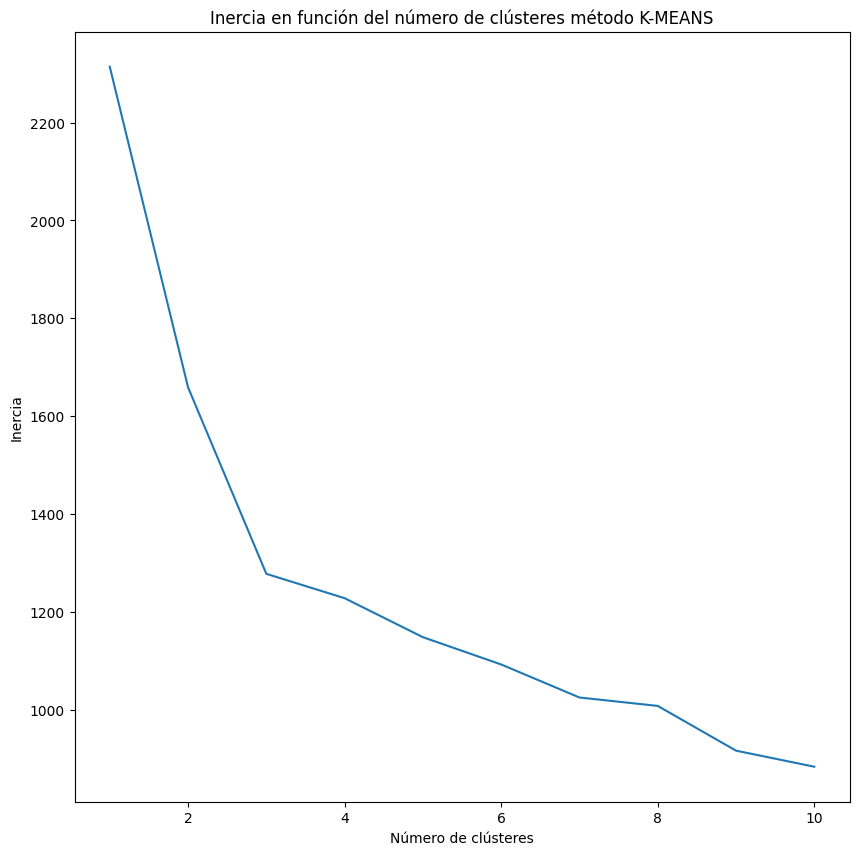

In [28]:
plt.figure(figsize=(10,10))
plt.plot(n_clusters, inercias)
plt.title('Inercia en función del número de clústeres método K-MEANS')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

## Coeficiente de la Silueta.

Para cada punto correspondiente a una instancia de los atributos de entrada, podemos definir el coeficiente de la silueta como:



a (cohesión) = distancia promedio de cada punto a todos los demás puntos en el mismo cluster.

b (separación) = distancia promedio de cada punto a todos los demás puntos en el cluster más cercano.

Dado esto, se dice que el coeficiente de la silueta (s) para cada punto (instancia) está dado por:

$$
s = \frac{b - a}{\max(a, b)}
$$


donde el valor de s puede variar entre -1 y 1,

El coeficiente de silueta puede variar entre -1 y 1. Un valor alto (cerca de 1) indica que el punto está bien ubicado dentro de su propio clúster y lejos de otros clústeres. Un valor cercano a 0 significa que el punto está cerca o en la frontera entre dos clústeres. Es decir, está casi igual de cerca de su clúster que del clúster vecino (punto en la frontera entre dos clústeres). Un valor negativo indica que el punto está más cerca de otro clúster que del suyo, en este caso, es probable que se haya realizado una asignación incorrecta de este punto a un clúster.

### Silhouette global (*Silhouette Score*)

El *silhouette score* del clustering entero es la media de los s (coeficiente de Silhouette) de todos los puntos. Para K-means buscamos el K (número de clústeres) con *silhouette score* más alto

### <span style="color:red">Se considera como número óptimo de clusters aquel que tiene el mayor Silhouette global (*Silhouette Score*).</span>


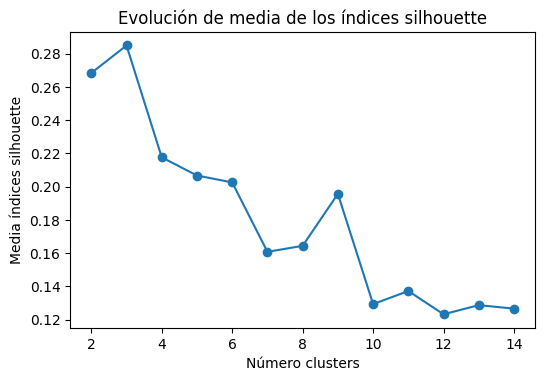

In [36]:
# Método silhouette para identificar el número óptimo de clusters
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = range(2, 15)   # rango de número de clústeres que queremos evaluar
valores_medios_silhouette = []    # lista vacía para guardar el valor del coeficiente de Silhouette global de cada n clústeres

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        init='k-means++',
                        n_clusters   = n_clusters, 
                        n_init       = 'auto', 
                        max_iter=300,
                        tol=0.0001,
                        random_state = 10,
                        algorithm='lloyd'
                    )
    cluster_labels = modelo_kmeans.fit_predict(X_scaled)
    silhouette_medio = silhouette_score(X_scaled, cluster_labels) # la media del silhouette s de todos los puntos del dataset.
    valores_medios_silhouette.append(silhouette_medio)
    
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

Para 2 clusters las etiquetas predichas por kmeans son: 
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1
 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

coeficiente de silhouette para cada una de las instancias (puntos) del dataset
[ 0.36304514  0.33032827  0.34162905  0.32035101  0.19489355  0.33940562
  0.33764291  0.2864873   0.33233905  0.38739283  0.37804436  0.30328175
  0.34476421  0.30024864  0.32382898  0.30655726  0.27349841  0.27981058
  0.30533238  0.31803785  0.37589522  0.24347636  0.40458526  0.35116816
  0.35011949  0.12056435  0.31564435  0.27104541  0.33520767  0.3789401
  0.31814569  0.34810952  0.32447824  0.21662609  0.29303325  0.38195646
  0.25420322  0.27510193  0.32199815  0.26241946  0.36650191  0

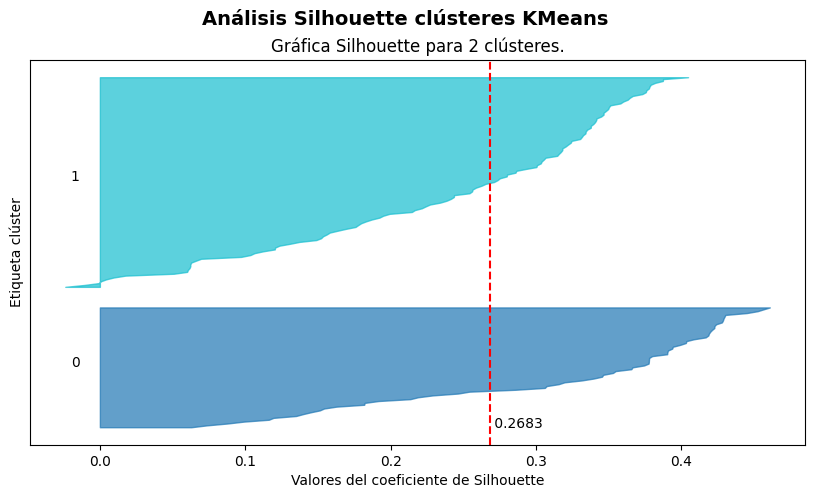

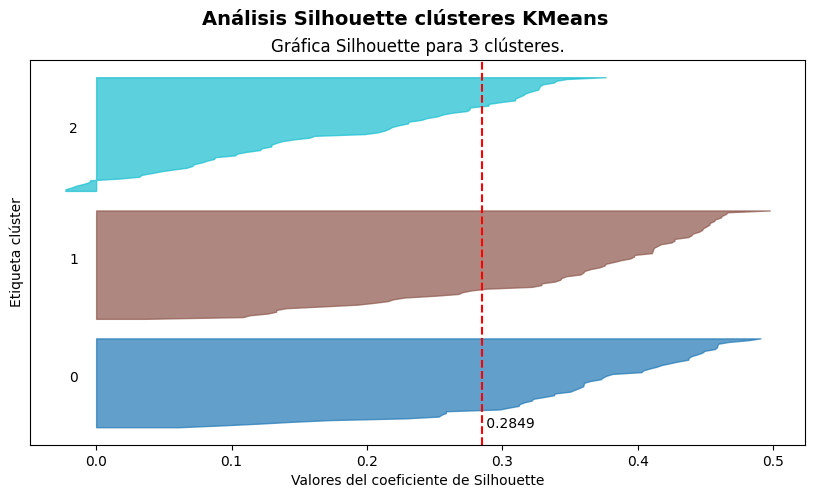

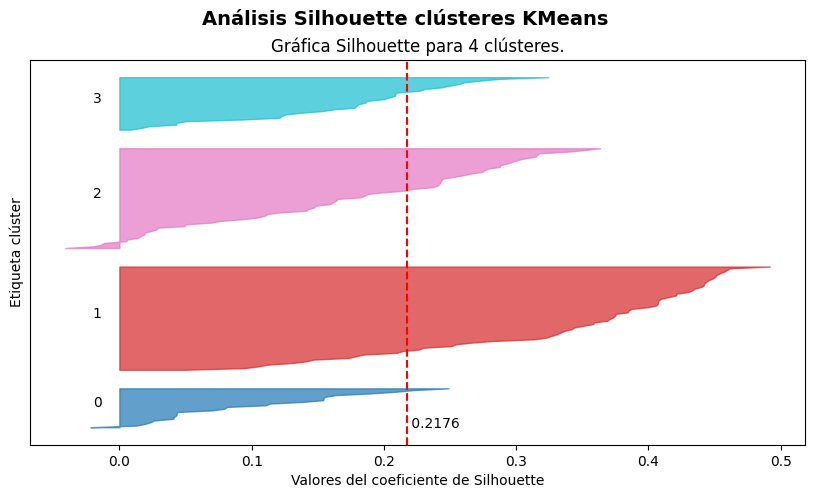

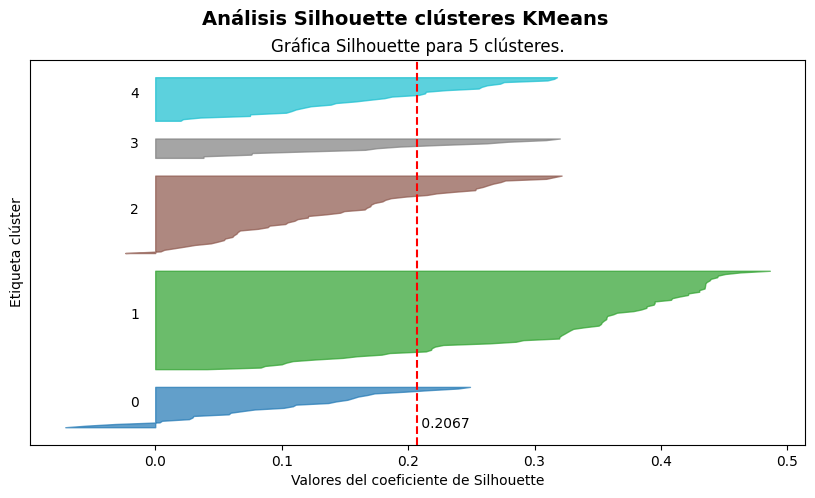

In [71]:
import matplotlib.cm as cm
rango_n_clusteres = [2, 3, 4, 5]

for n_clusteres in rango_n_clusteres: #Para 2,3,4,5 clústeres

    fig, ax = plt.subplots(figsize=(10,5))  # fig es el lienzo de dibujo, donde estrán cada uno de los conj. de ejes ax
    # configuramos el eje Y: yticks son marcas o números del eje Y (0, 1, 2, …).
    # La lista vacía [] significa no muestrar marcas ni números en el eje Y    
    ax.set(yticks = []) 
  
    cluster = KMeans(n_clusters=n_clusteres, random_state=10, n_init="auto") # instanciamos un objeto Kmeans con n_clusteres
    cluster_labels = cluster.fit_predict(X_scaled)                           #predecimos etiquetas de clúster a cada punto del dataset escalado

    print(f'Para {n_clusteres} clusters las etiquetas predichas por kmeans son: \n',cluster_labels) # etiquetas puntos para un número de n_clusteres
      
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)  #coeficiente de silhouette instancias (puntos) del dataset
    print('\ncoeficiente de silhouette para cada una de las instancias (puntos) del dataset')
    print(sample_silhouette_values) # Visualizamos cada uno de los valores de estos coeficientes
    silhouette_medio = silhouette_score(X_scaled, cluster_labels)  # calculamos la media de los cofecientes silhouette para un número de n_clusteres
    print(
        f"\nPara {n_clusteres} clústeres el silhouette_score es {silhouette_medio} \n"
    )

    #DIBUJAMOS LAS GRÁFICAS DE CLUSTERS-COEFICIENTES DE SILHOUETTE-SILHOUETTE SCORE
    #y_lower = 10
    y_lower = 0  #limite interior en el eje y para dibujar el clúster i
    for i in range(n_clusteres):#para cada uno de cada conjunto de clusters (2 clústers, se ejecuta 2 veces con valores 0,1..., etc)
       
        cluster_i_silhouette_values = sample_silhouette_values[cluster_labels == i]#valores coeficiente silhouette para el cluster i

        cluster_i_silhouette_values.sort()#ordenamos los valores de los coeficientes del clúster i

        size_cluster_i = len(cluster_i_silhouette_values) #tamaño del conjunto de puntos del clúster con etiqueta i 

        print(f'El tamaño del cluster {i} es: {size_cluster_i}\n')

        # y_upper = y_lower + número de puntos del clúster i
        y_upper = y_lower + size_cluster_i #limite superior en el eje y para dibujar el clúster i.
        #elegimos un color i del mapa de colores tab10 para cada clúster
        cmap = plt.get_cmap("tab10", n_clusteres)
        color = cmap(i)  # color i-ésimo

        # para cada “fila” en el eje y se dibuja una barra horizontal desde x=0 hasta el valor silhouette.
        # np.arange(y_lower, y_upper) no incluye y_upper, por eso salen justo y_upper - y_lower elementos, que es size_cluster_i.
        ax.fill_betweenx(  # en el conjunto de ejes ax
            np.arange(y_lower, y_upper), # valores del eje y donde se dibuja el bloque. genera size_cluster_i posiciones (una por valor silhouette).
                                         # Ejemplo: si y_lower=40 y y_upper=60, produce: 40, 41, 42, …, 59 (uno por cada punto del cluster)
            0,                           # límite izquierdo en el eje x (arranca desde 0)
            cluster_i_silhouette_values, # límite derecho en el eje x (el valor silhouette de cada punto)
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
   
        ax.text(-0.02, y_lower + 0.5 * size_cluster_i, str(i)) # etiqueta de cada clúster
        y_lower = y_upper + 10 # deja un hueco de 10 entre clústeres    

    ax.set_title(f"Gráfica Silhouette para {n_clusteres} clústeres.")
    ax.set_xlabel("Valores del coeficiente de Silhouette")
    ax.set_ylabel("Etiqueta clúster")
    
    # Línea vertical para indicar el valor de coeficiente de Silhoutte del dataset   
    ax.axvline(x=silhouette_medio, color="red", linestyle="--")
    ax.text(silhouette_medio, 0, f' {silhouette_medio:.4f}')  # etiqueta de cada valor de silhoutte medio (para un número n_clústeres) 
    plt.suptitle(
        "Análisis Silhouette clústeres KMeans",
        fontsize=14,
        fontweight="bold"
    )

plt.show()

## **Métodos de agrupamiento jerárquico (hierarchical clustering)**
Una de los problemas que tiene el método k-means es que necesita definir un número de clústeres desde un primer momento. Existen otras técnicas que no tienen este requisito, como por ejemplo la agrupación jerárquica. Además, la agrupación jerárquica genera siempre los mismos clústeres, mientras que el agrupamiento de k-means puede dar lugar a grupos distintos dependiendo de cómo se inicien los centroides.

La agrupación jerárquica es una familia general de algoritmos de clustering que actúan construyendo **grupos anidados**, fusionándolos o dividiéndolos sucesivamente. Hay dos tipos de agrupación jerárquica:
- **Agrupación aglomerativa**: comienza haciendo un grupo de cada punto individual y va fusionando iterativamente los grupos similares para formar grupos cada vez más grandes.
- **Agrupación divisiva**: al contrario que en el caso anterior.

La jerarquía de grupos se representa como un árbol (o dendrograma). La raíz del árbol es el grupo único que reúne todas las muestras, mientras que las hojas son los grupos con una sola muestra. 

### **Funcionamiento**

La técnica de Agglomerative Clustering realiza una agrupación jerárquica utilizando un enfoque de abajo hacia arriba: cada observación comienza en su propio grupo y los grupos se van fusionando sucesivamente.

El clustering jerárquico no requiere que se fije a priori el número de clústers.

● Progresivamente une los dos clústers más cercanos en un solo clúster.
  También puede proceder al revés, dividiendo clústeres, pero lo que se usa con mucha más frecuencia es el clústering aglomerativo.
  
● Es necesario usar una medida de similaridad para determinar qué clústeres se funden/separan en cada paso. Dados dos clústeres, esta distancia puede  ser:

– Mínima distancia entre un elemento de un clúster y un elemento del otro clúster
– Máxima distancia entre un elemento de un clúster y un elemento del otro clúster
– Distancia entre los centroides de los clústeres
– etc.

### **Criterios de agrupamiento**

Existen muchos métodos diferentes que se pueden utilizar para ir vinculando los grupos en base a la similitud entre unos y otros. Scikit Learn cuenta con los 4 métodos siguientes:

Vinculación de Ward: minimiza la suma de diferencias cuadradas dentro de los grupos. Es un enfoque que minimiza la varianza y, en este sentido, es similar a la función objetivo de k-medias, pero se aborda con un enfoque jerárquico aglomerativo.

Vinculación de enlace máximo o completo: minimiza la distancia máxima entre observaciones de pares de grupos.

Vinculación de promedio: minimiza el promedio de las distancias entre todas las observaciones de pares de grupos.

Vinculación de enlace mínimo, simple o único: minimiza la distancia entre las observaciones más cercanas de pares de grupos.

Los enlaces mínimos, promedio y máximos se pueden combinar con una variedad de distancias (o afinidades), como la distancia euclidiana (l2) o la distancia de Manhattan (o Cityblock, o l1).

La distancia l1 suele ser buena para características escasas o ruido escaso: es decir, muchas de las características son cero, como en la minería de texto que analiza apariciones de palabras raras. Lógicamente, es conveniente utilizar una métrica de distancia que maximice la distancia entre muestras de diferentes clases y la minimice dentro de cada clase.

### **Criterios de parada**

Para evitar llegar a combinar todos los puntos de datos en un único grupo, hay que dejar de combinar clústeres en algún momento. Scikit-learn cuenta con dos opciones para esto:

1. Detenerse después de alcanzar un número concreto de clústeres (hiperparámetro n_clusters).

2. Establecer un valor de umbral para la vinculación (hiperparámetro distance_threshold). Si la distancia entre dos grupos está por encima del umbral, estos grupos ya no se fusionarán.

### **Hiperparámetros**

class sklearn.cluster.AgglomerativeClustering(n_clusters=2,

                                              *,
                                              
                                              affinity='euclidean',
                                              
                                              memory=None,
                                              
                                              connectivity=None,
                                              
                                              compute_full_tree='auto',
                                              
                                              linkage='ward',
                                              
                                              distance_threshold=None)

### **Hiperparámetro n_clusters**

El número de grupos que se van a encontrar. Debe ser None si el hiperparámetro distance_threshold no es None, es decir, solo se puede utilizar uno de los dos criterios de parada.

### **Hiperparámetro affinity**

Métrica utilizada para calcular la similitud. Puede ser “euclidean”, “l1”, “l2” o “manhattan”, entre otras opciones. Si el hiperparámetro "linkage" es “ward”, solo se acepta “euclidean”.

### **Hiperparámetro linkage**

Es el criterio de vinculación (**agrupamiento**) a utilizar para formar los grupos.

Puede ser una opción de las siguientes: {“ward”, “complete”, “average”, “single”}. Por defecto es ”ward”.

Este hiperparámetro determina qué criterio de distancias se va a utilizar entre grupos de puntos. El algoritmo combinará pares de clústeres que minimicen este criterio.

1. "ward" utiliza el criterio de vinculación de Ward.

2. "complete" utiliza el criterio de vinculación de enlace máximo o completo.

3. "average" utiliza el criterio de vinculación de vinculación de promedio.

4. "single" utiliza el criterio de vinculación de enlace mínimo, simple o único.

### **Hiperparámetro distance_threshold

Permite especificar el threshold o límite por encima del cual los clústeres no serán combinados. Si es distinto de "None", el hiperparámetro n_clusters debe ser "None" y compute_full_tree debe ser "True".



In [166]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering

La mayoría de los métodos clúster con muy sensibles al hecho de que las variables no estén todas medidas en las mismas unidades y que la variabilidad sea muy diferente. Si queremos que todas las variables tengan la misma importancia en el análisis, podemos estandarizar los datos.

In [44]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(X)
scaled_data.shape

(178, 13)

In [45]:
scaled_data

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [46]:
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_complete_clustering_matrix = linkage(scaled_data, method="complete", metric="euclidean")
linkage_average_clustering_matrix = linkage(scaled_data, method="average", metric="euclidean")
linkage_single_clustering_matrix = linkage(scaled_data, method="single", metric="euclidean")
linkage_ward_clustering_matrix = linkage(scaled_data, method="ward",  metric="euclidean")
linkage_ward_clustering_matrix
linkage_complete_clustering_matrix

array([[  9.        ,  47.        ,   1.16411367,   2.        ],
       [131.        , 133.        ,   1.19160238,   2.        ],
       [ 11.        ,  12.        ,   1.20935571,   2.        ],
       [ 15.        ,  53.        ,   1.22551046,   2.        ],
       [ 92.        , 107.        ,   1.24538798,   2.        ],
       [ 34.        ,  37.        ,   1.26841838,   2.        ],
       [  0.        ,  20.        ,   1.28789316,   2.        ],
       [ 16.        ,  17.        ,   1.2917937 ,   2.        ],
       [164.        , 172.        ,   1.30048379,   2.        ],
       [ 22.        ,  29.        ,   1.33566687,   2.        ],
       [ 40.        ,  56.        ,   1.34447772,   2.        ],
       [104.        , 116.        ,   1.3521749 ,   2.        ],
       [ 23.        ,  24.        ,   1.36268788,   2.        ],
       [ 27.        ,  38.        ,   1.3653111 ,   2.        ],
       [140.        , 142.        ,   1.36740174,   2.        ],
       [ 63.        ,  98

In [47]:
linkage_ward_clustering_matrix.shape

(177, 4)

A (n-1) by 4 matrix Z is returned. (En este caso se obtiene una matriz de (n-1) x 4 = (178-1) x 4 = 177 x 4)

At the i-th iteration, clusters with indices Z[i, 0] and Z[i, 1] are combined to form cluster n+i. 

A cluster with an index less than n corresponds to one of the n  original observations.

The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].

The fourth value Z[i, 3] represents the number of original observations in the newly formed cluster.

In its first iteration the linkage algorithm decided to merge the two clusters (original samples here) with indices 9 and 47, as they only had a distance of 1.16411367. This created a cluster with a total of 2 samples.

In the second iteration the algorithm decided to merge the clusters (original samples here as well) with indices 131 and 133, which had a distance of 1.19160238. This again formed another cluster with a total of 2 samples.

The indices of the clusters until now correspond to our samples. Remember that we had a total of 178 samples, so indices 0 to 177. Let's have a look at the first 28 iterations:

In [48]:
linkage_ward_clustering_matrix[:28]

array([[  9.        ,  47.        ,   1.16411367,   2.        ],
       [131.        , 133.        ,   1.19160238,   2.        ],
       [ 11.        ,  12.        ,   1.20935571,   2.        ],
       [ 15.        ,  53.        ,   1.22551046,   2.        ],
       [ 92.        , 107.        ,   1.24538798,   2.        ],
       [ 34.        ,  37.        ,   1.26841838,   2.        ],
       [  0.        ,  20.        ,   1.28789316,   2.        ],
       [ 16.        ,  17.        ,   1.2917937 ,   2.        ],
       [164.        , 172.        ,   1.30048379,   2.        ],
       [ 22.        ,  29.        ,   1.33566687,   2.        ],
       [ 40.        ,  56.        ,   1.34447772,   2.        ],
       [104.        , 116.        ,   1.3521749 ,   2.        ],
       [ 23.        ,  24.        ,   1.36268788,   2.        ],
       [ 27.        ,  38.        ,   1.3653111 ,   2.        ],
       [140.        , 142.        ,   1.36740174,   2.        ],
       [ 63.        ,  98

We can observe that until iteration 28 the algorithm only directly merged original samples. We can also observe the monotonic increase of the distance.

In iteration 29 the algorithm decided to merge cluster indices 106 with 189

In [49]:
linkage_ward_clustering_matrix[28]

array([106.        , 189.        ,   1.59053586,   3.        ])

All indices idx >= len(X) actually refer to the cluster formed in linkage_ward_clustering_matrix[idx - len(X)] = linkage_ward_clustering_matrix[idx - 178].

This means that while idx 177 corresponds to X[177] that idx 178 corresponds to the cluster formed in linkage_ward_clustering_matrix[178-178]=linkage_ward_clustering_matrix[0], idx 179 to linkage_ward_clustering_matrix[1], 180 to linkage_ward_clustering_matrix[2], ...

Hence, the merge iteration 28 merged sample 106 to our samples 104 and 116 that were previously merged in iteration 12 corresponding to Z[11] (189 - 178).

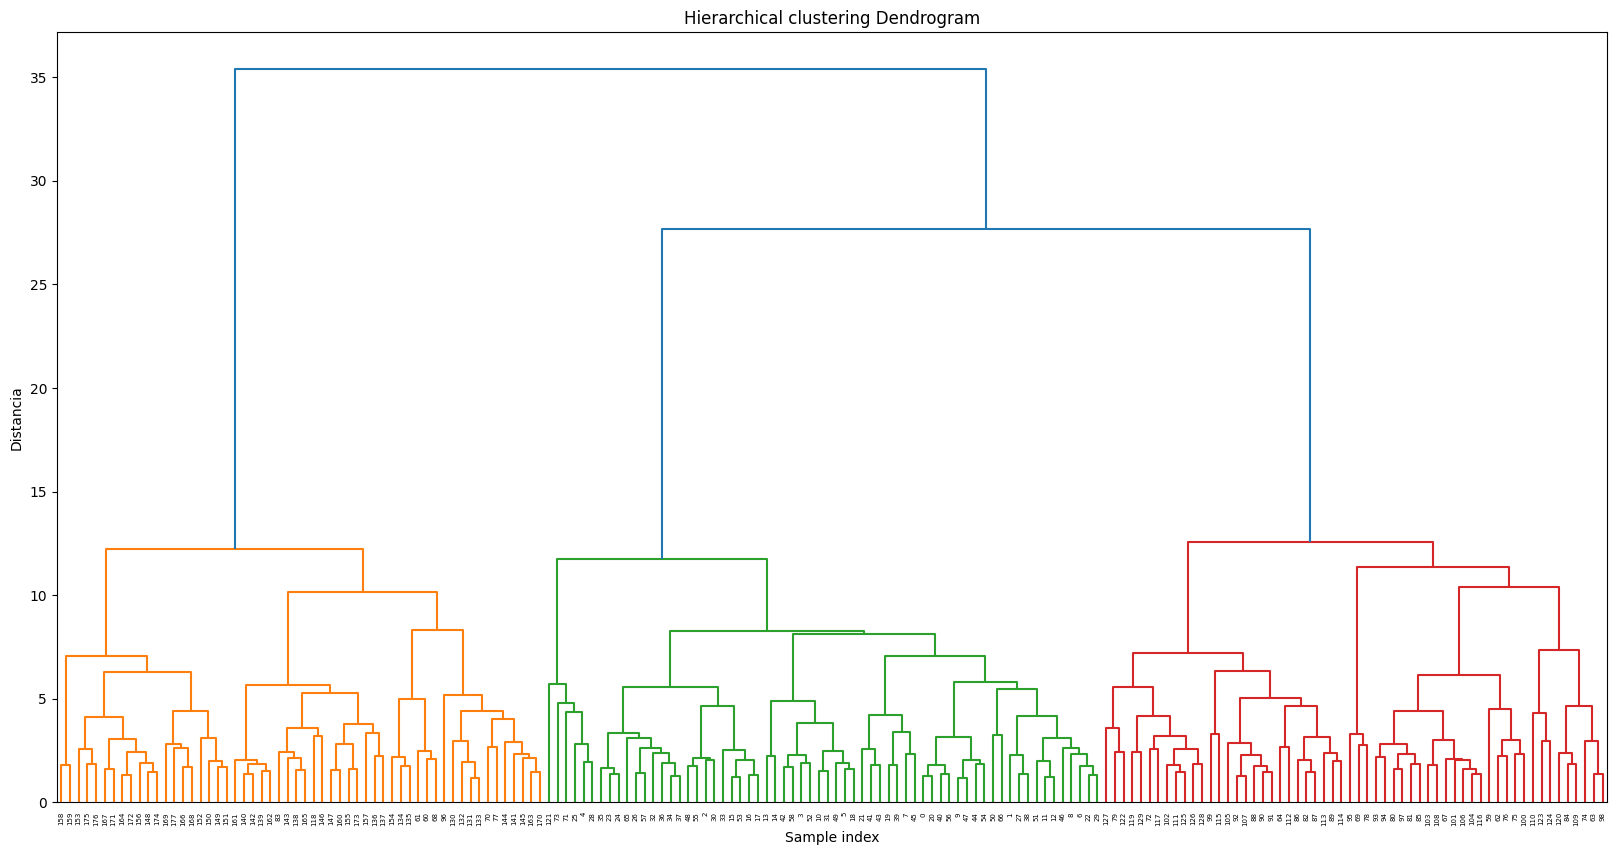

In [50]:
plt.figure(figsize=(20,10))
dendrogram(linkage_ward_clustering_matrix)
plt.title("Hierarchical clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distancia")
plt.show()

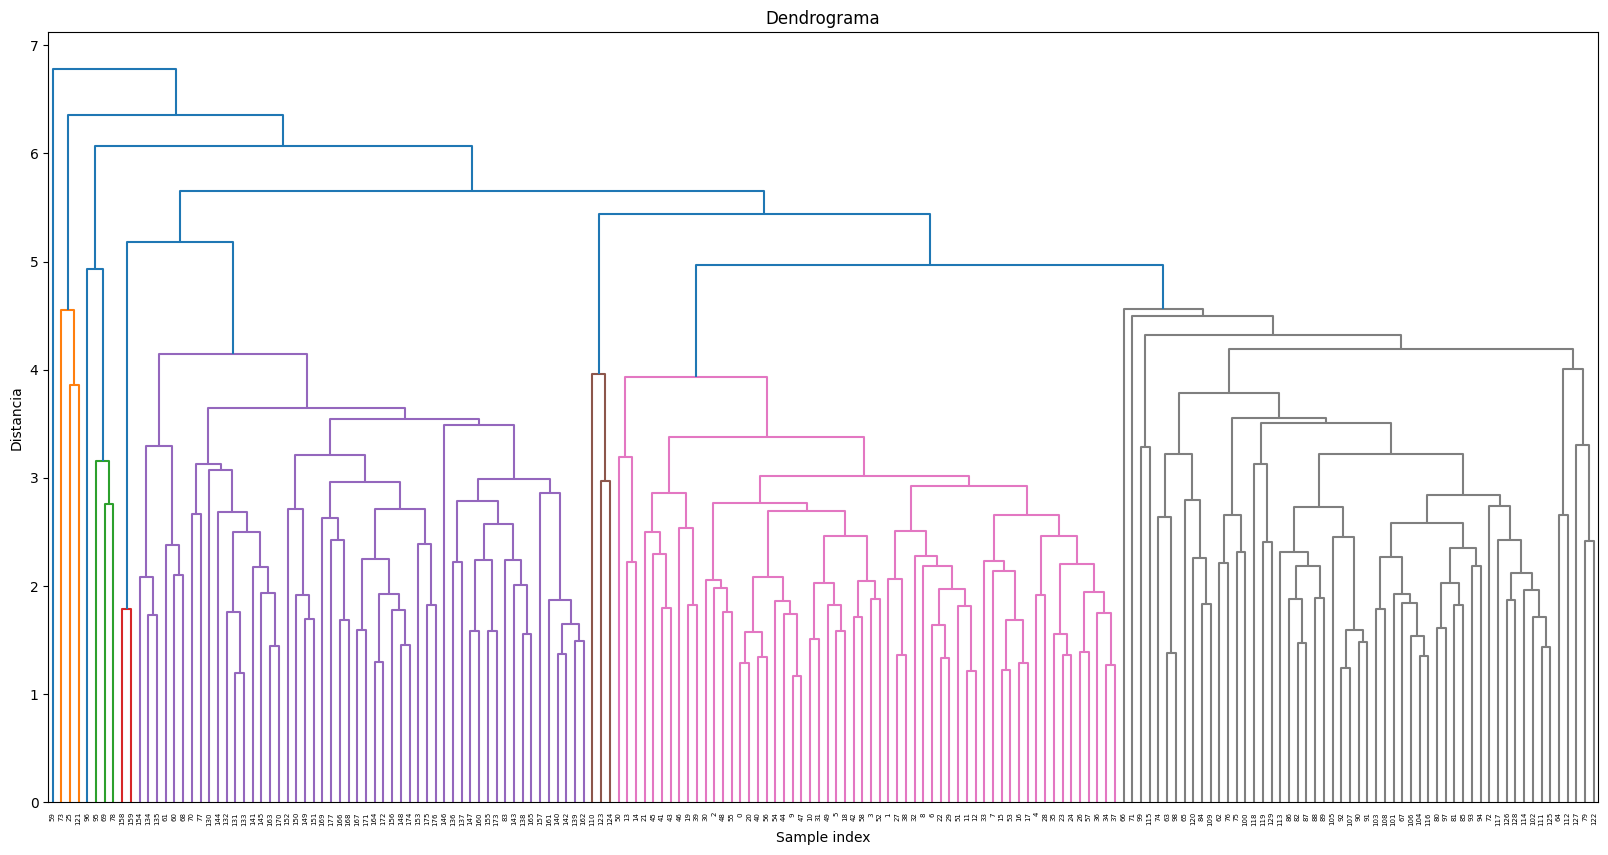

In [51]:
plt.figure(figsize=(20,10))
dendrogram(linkage_average_clustering_matrix)
plt.title("Dendrograma")
plt.xlabel("Sample index")
plt.ylabel("Distancia")
plt.show()

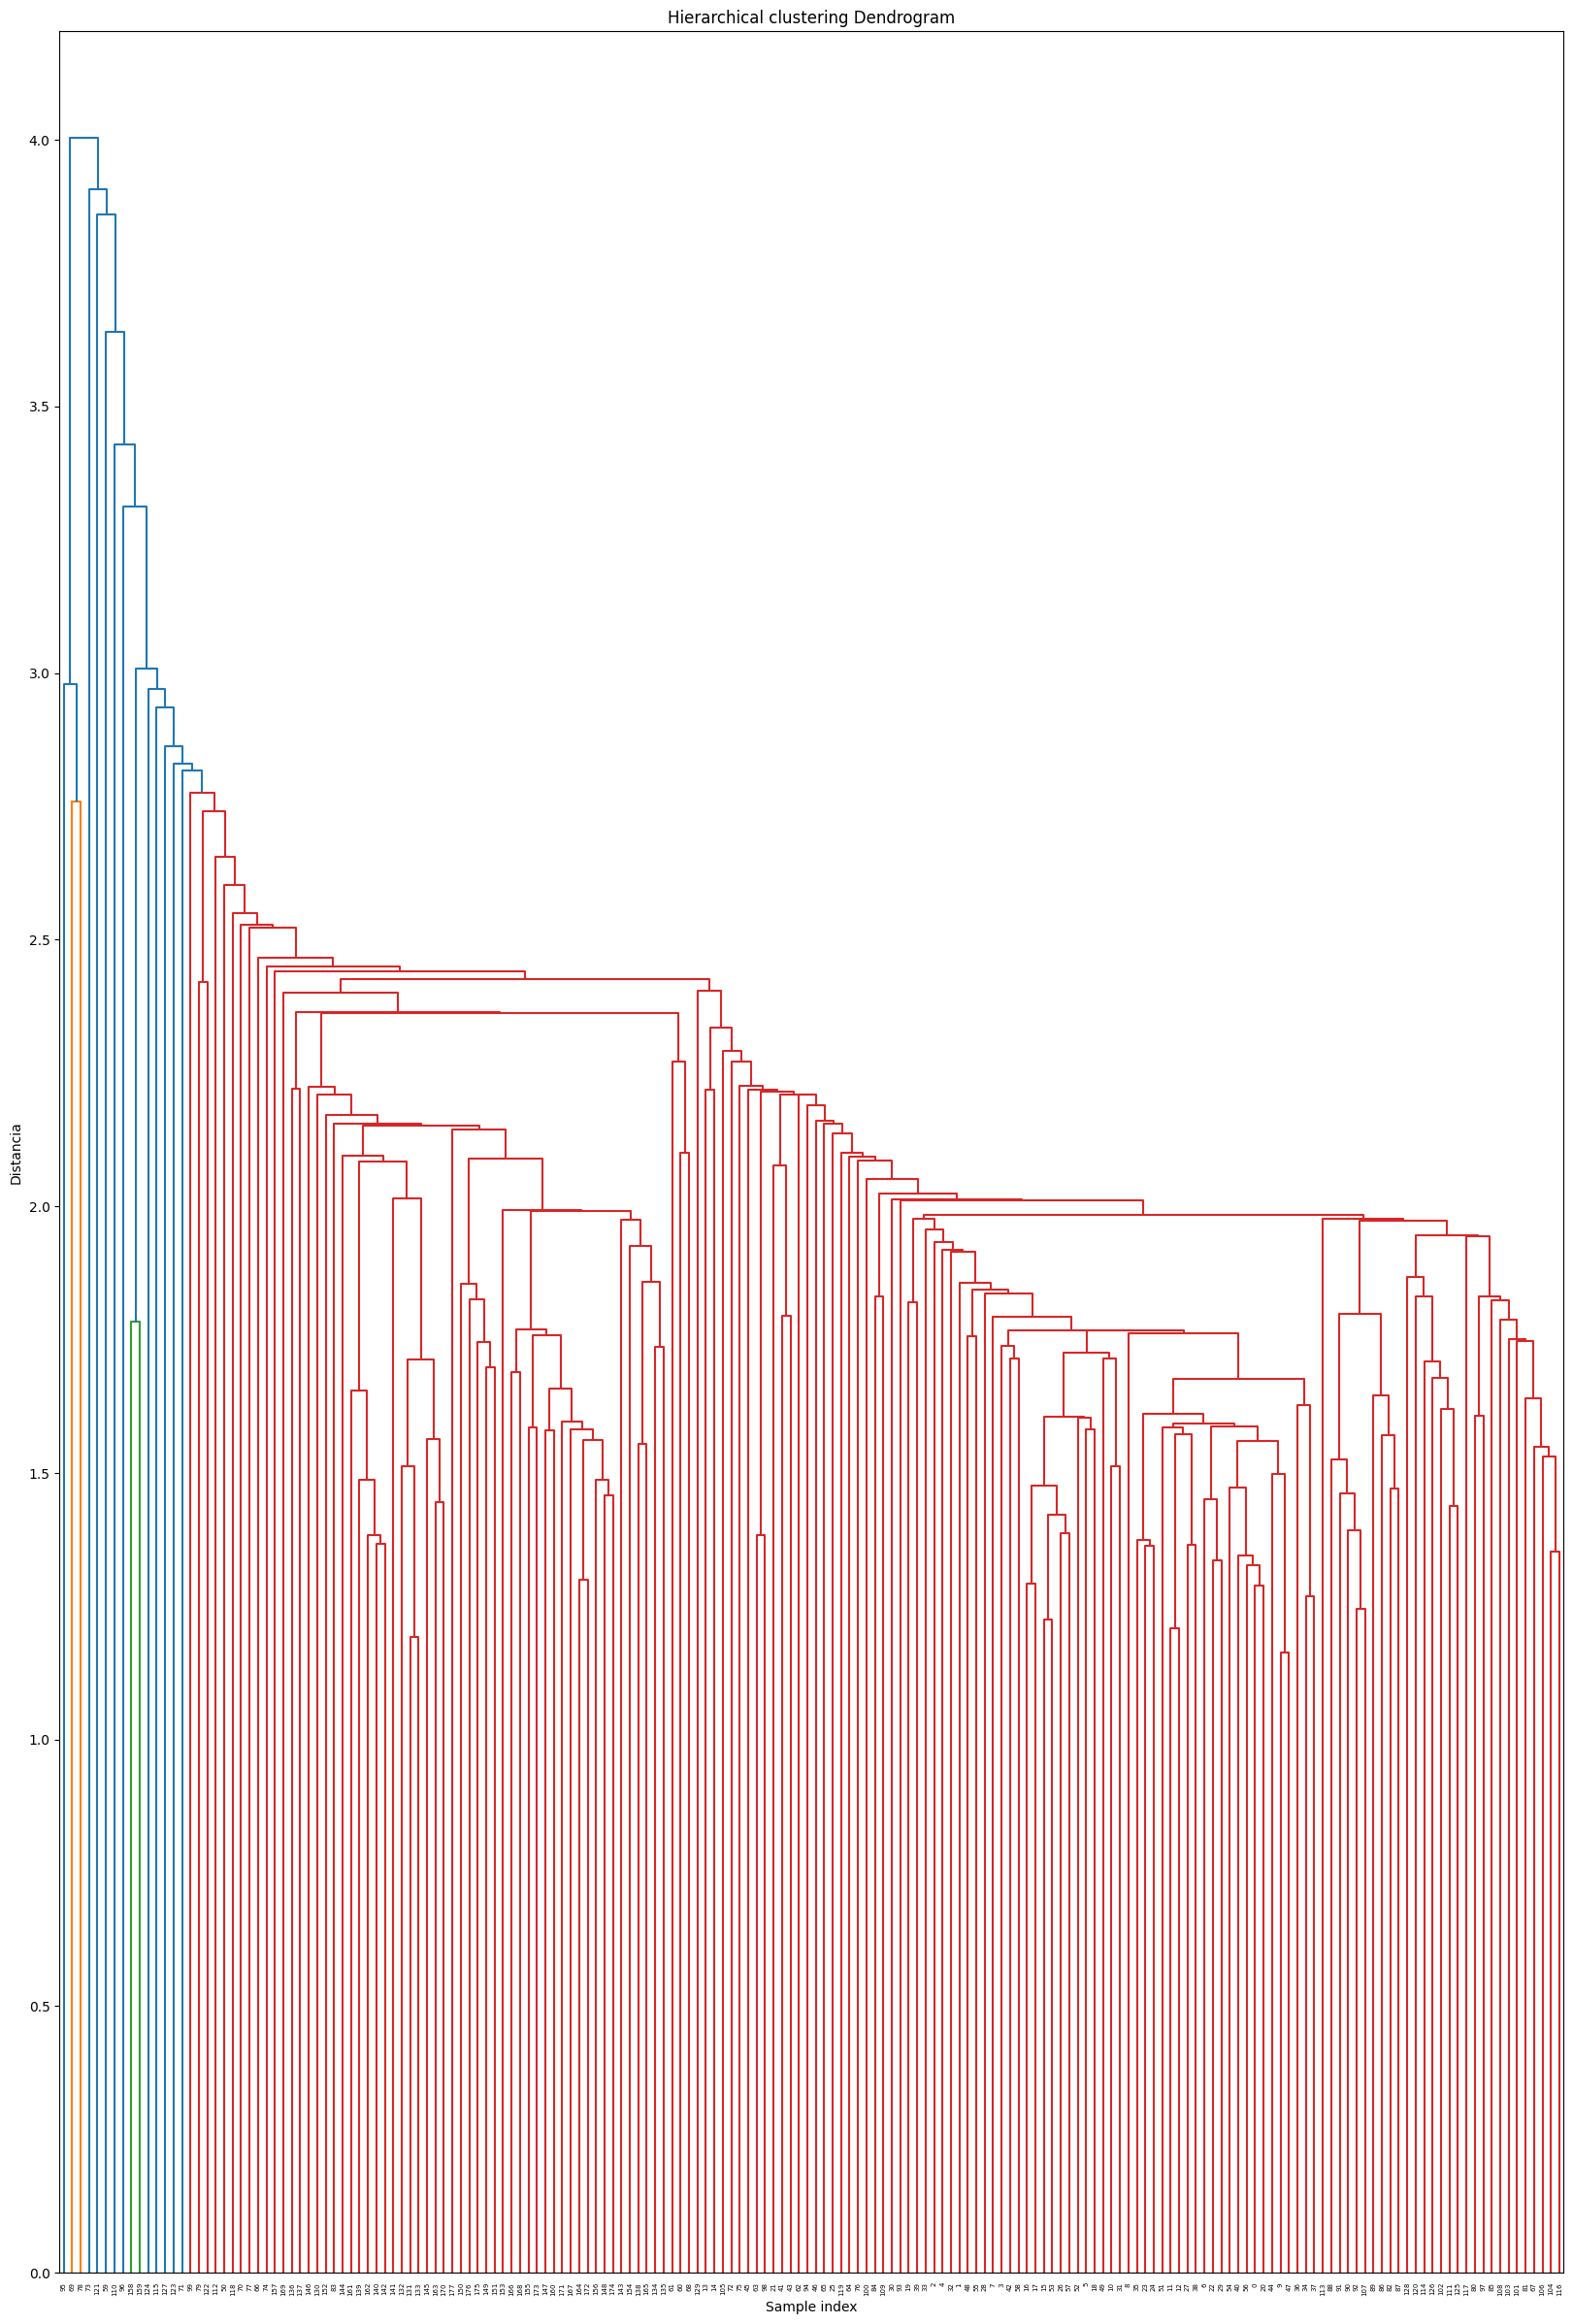

In [52]:
plt.figure(figsize=(20,30))
dendrogram(linkage_single_clustering_matrix)
plt.title("Hierarchical clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distancia")
plt.show()

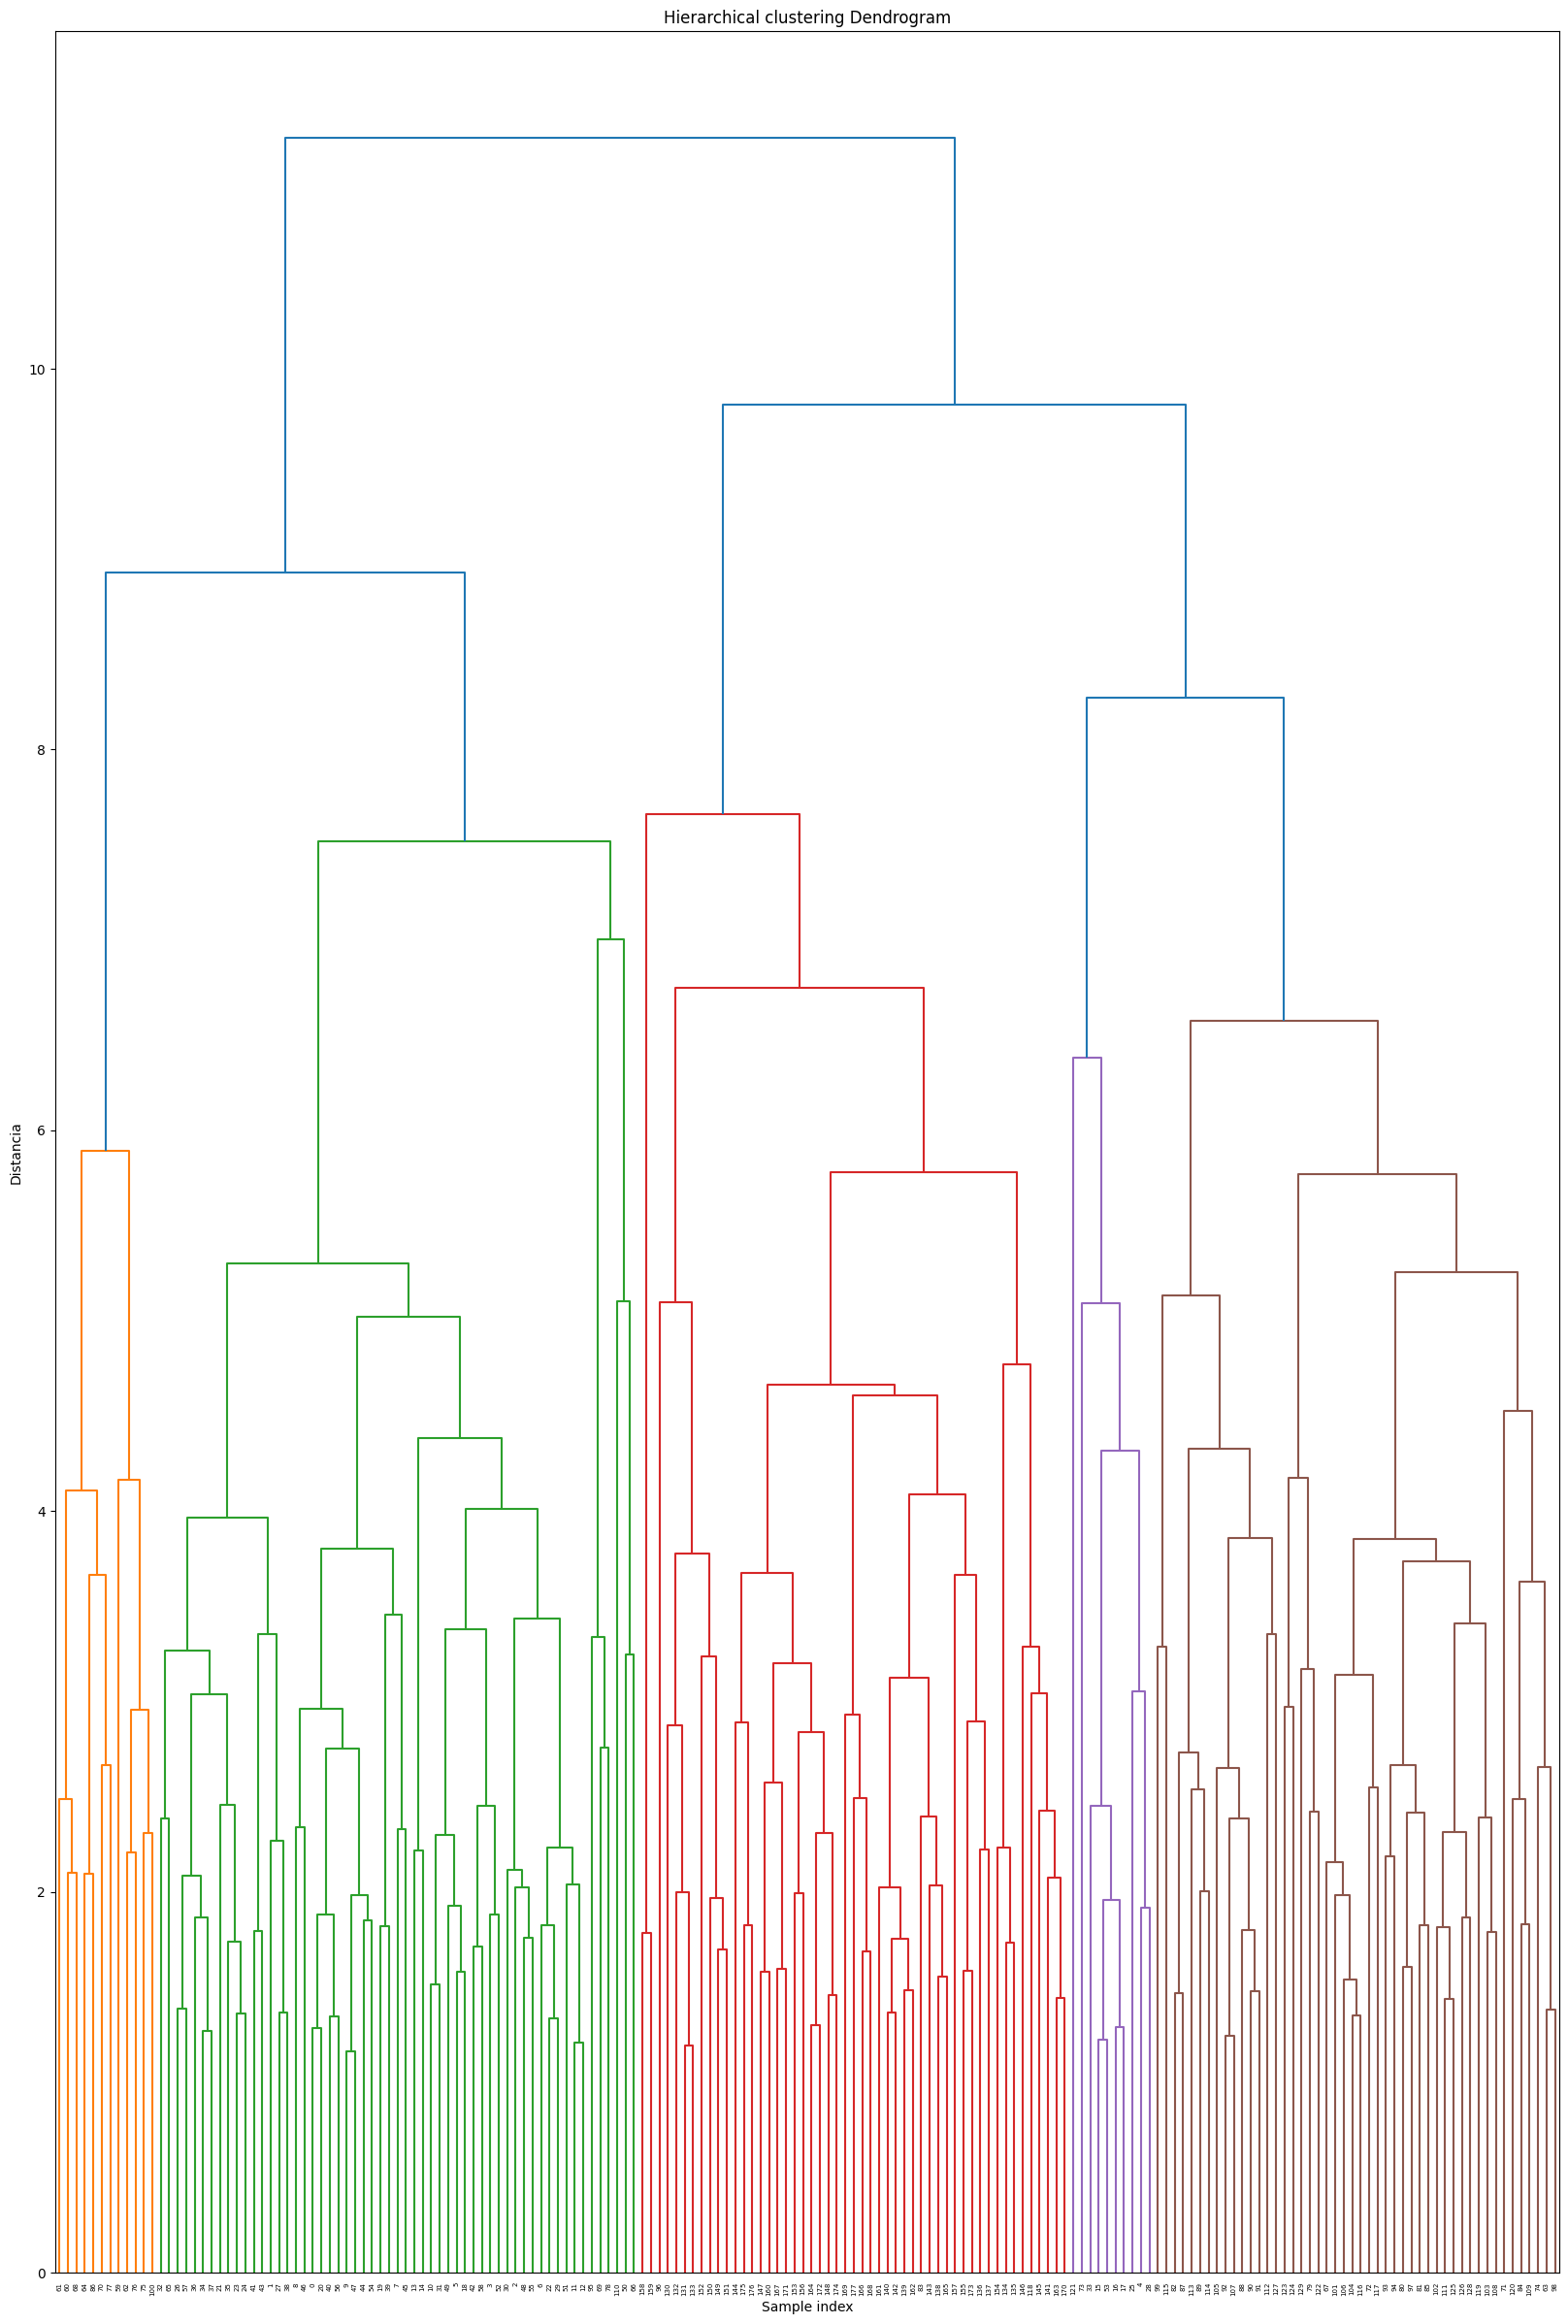

In [53]:
plt.figure(figsize=(20,30))
dendrogram(linkage_complete_clustering_matrix)
plt.title("Hierarchical clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distancia")
plt.show()

### **REDUCCIÓN DE LA DIMENSIONALIDAD**

La reducción de la dimensionalidad es una de las técnicas básicas de preprocesado de datos, que consiste en la reducción del número de variables.

A priori, puede parecer que cuanta más información, mejor. Sin embargo, en la mayoría de los casos no es así. De hecho, hay varias razones por las que puede ser interesante tratar de reducir el número de dimensiones del conjunto de datos:
- Se reduce la complejidad, con lo que el modelo y sus resultados se hacen más fácilmente interpretables.
- Por razones de ahorro, tanto en coste como en tiempo. Reduciendo las dimensiones, se mejora el rendimiento computacional.
- Se identifican y eliminan las variables irrelevantes, reduciendo el ruido del dataset original. Es importante tener en cuenta que, en ocasiones, el mejor modelo posible no es el que tiene en cuenta más variables, sino aquel que incluye únicamente la información "de calidad". Aquí entra en juego la *Maldición de la dimensionalidad*.

Normalmente, un modelo de Machine Learning requiere una información abundante al principio, con el fin de realizar predicciones más precisas. Sin embargo, llegado a cierto punto, el rendimiento del modelo disminuirá conforme aumente el número de variables. Este fenómeno es lo que se conoce como **"maldición de la dimensionalidad”.**

La maldición de la dimensionalidad tiene lugar porque, al aumentar el número de variables y mantenerse el mismo número de muestras, la densidad de la muestra disminuye exponencialmente, volviéndose cada vez más dispersa. A partir de una muestra dispersa, el modelo de Machine Learning posiblemente obtendrá una solución que, aparentemente, sea muy buena. Sin embargo, lo que estará sucediendo en realidad es que se habrá producido un sobreajuste. 

### Análisis de componentes principales (PCA)

El Análisis de Componentes Principales (ACP) – o en su versión inglesa, Principal Component Analysis (PCA) – es un método estadístico cuya utilidad radica en la reducción de la dimensionalidad de la base de datos (BDD) con la que estamos trabajando. Esta técnica se utiliza cuando queremos simplificar la base de datos, ya sea para elegir un menor número de predictores para pronosticar una variable objetivo, o para comprender una BDD de una forma más simple.

La técnica PCA forma parte de los algoritmos de aprendizaje no supervisado de Machine Learning, y se utilizaría solo con aquellas variables numéricas disponibles.

El método de PCA permite por lo tanto “condensar” la información aportada por múltiples variables en solo unas pocas componentes. Esto lo convierte en un método muy útil de aplicar previa utilización de otras técnicas estadísticas tales como regresión, clustering, etc.

El proceso de PCA identifica aquellas direcciones en las que la varianza es mayor. Como la varianza de una variable se mide en su misma escala elevada al cuadrado, si antes de calcular las componentes no se estandarizan todas las variables para que tengan media 0 y desviación estándar 1, aquellas variables cuya escala sea mayor dominarán al resto. De ahí que sea recomendable estandarizar siempre los datos.


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
print(scaled_data.shape)
scaled_data

In [ ]:
pca = PCA()
pca

In [ ]:
pca.fit(scaled_data)

In [ ]:
print(pca.components_.shape)
pca.components_

In [ ]:
pca.explained_variance_ratio_*100

En el contexto del Análisis de Componentes Principales (PCA), la "Varianza Explicada" se refiere a la proporción de la varianza total de los datos originales que cada componente principal logra capturar. El PCA transforma los datos a un nuevo sistema de coordenadas, y los componentes principales son las direcciones en este nuevo espacio donde los datos varían más. La varianza explicada nos indica cuánta información de los datos originales se mantiene en cada componente.

La reducción de dimensiones es crucial antes de realizar un análisis de cluster porque al trabajar con un gran número de dimensiones, el espacio se vuelve tan "grande" que la distancia entre puntos se vuelve menos significativa, un fenómeno conocido como la "maldición de la dimensionalidad". Esto puede hacer que los algoritmos de clustering, como K-Means, funcionen mal ya que se basan en medidas de distancia para formar grupos o clusters.

In [ ]:
#Gráfico de la varianza acumulada
sns.set(style="darkgrid")
plt.figure(figsize=(10,5))
plt.plot(range(1,len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza Acumulada Explicada por los Componentes')
plt.xlabel('Número de Componenetes')
plt.ylabel('Varianza Explicada Acumulada')

El gráfico de Varianza Explicada Acumulada, como el que se muestra en la imagen de arriba, es una herramienta útil para determinar cuántas dimensiones debemos conservar. En este gráfico, podemos ver que la mayor parte de la información (varianza) está contenida en las primeras componentes. Por ejemplo, podríamos decidir utilizar solo las primeras 5 o 6 componentes si juntas explican, digamos, más del 80% de la varianza. Esto es relevante en K-Means Clustering porque al reducir las dimensiones conservando la mayor parte de la información, el algoritmo puede identificar clusters más significativos y diferenciados, lo cual es especialmente importante en la segmentación de mercados donde queremos encontrar grupos distintos y manejables de clientes.

La varianza explicada por cada componente nos indica la cantidad de información o variabilidad que cada uno de estos nuevos ejes captura del conjunto de datos original. Al observar la varianza acumulada, podemos decidir cuántos componentes principales son necesarios para describir una buena parte de la variabilidad de los datos sin incurrir en la complejidad de manejar un gran número de variables. Esto simplifica el análisis y nos permite aplicar técnicas de clusterización de manera más eficiente.

In [ ]:
pca4 = PCA(n_components=4)
pca4

In [ ]:
pca4.fit(scaled_data)

In [ ]:
pca4.components_

In [ ]:
df_pca4 = pd.DataFrame(data=pca4.components_,
                       columns=X.columns.values,
                      index=["componente 1", "componente 2", "componente 3", "componente 4"])
df_pca4

In [ ]:
plt.figure(figsize=(20,10))
mapa = sns.heatmap(df_pca4,
                  annot = True,
                  cmap = 'RdBu',
                  vmax=1,
                  vmin=-1)

In [ ]:
score_pca4= pca4.transform(scaled_data)

In [ ]:
score_pca4

### **Variables latentes**

Las variables latentes son, en esencia, características subyacentes o factores no observados directamente pero que inferimos a partir de las variables que sí podemos medir. Pensemos en algo abstracto como la "paz". No podemos medirla directamente, pero podríamos inferirla a través de variables observables como la ausencia de conflictos, niveles de cooperación entre comunidades y tasas de criminalidad.

Ahora, ¿Cómo pasamos de las variables originales a estas latentes? Aquí es donde entra en juego el Análisis de Componentes Principales (PCA). PCA nos ayuda a reducir la complejidad de nuestros datos, transformando muchas variables posiblemente correlacionadas en un número menor de variables no correlacionadas llamadas componentes principales. Estos componentes representan las direcciones en las que los datos varían más y capturan la esencia o las "variables latentes" de nuestro conjunto de datos.

### **Análisis de variables latentes con la ayuda de ChatGPT**

Estoy haciendo un análisis de PCA sobre una base de ingredientes de un vino y su calidad. Voy a darte la matriz de correlación entre los ingredientes de cada vino y la calidad del vino correspondiente a esos ingredientes. También voy a darte la descripción de las variables que representan cada ingrediente. Con estos elementos, quiero que asignes una etiqueta intuitiva que resuma la variable latente de cada ingrediente y luego des una descripción de estas.

Alcohol	Malicacid	Ash	Alcalinity_of_ash	Magnesium	Total_phenols	Flavanoids	Nonflavanoid_phenols	Proanthocyanins	Color_intensity	Hue	0D280_0D315_of_diluted_wines	Proline
componente 1	0.144329	-0.245188	-0.002051	-0.239320	0.141992	0.394661	0.422934	-0.298533	0.313429	-0.088617	0.296715	0.376167	0.286752
componente 2	0.483652	0.224931	0.316069	-0.010591	0.299634	0.065040	-0.003360	0.028779	0.039302	0.529996	-0.279235	-0.164496	0.364903
componente 3	-0.207383	0.089013	0.626224	0.612080	0.130757	0.146179	0.150682	0.170368	0.149454	-0.137306	0.085222	0.166005	-0.126746
componente 4	-0.017856	0.536890	-0.214176	0.060859	-0.351797	0.198068	0.152295	-0.203301	0.399057	0.065926	-0.427771	0.184121	-0.232071


Los atributos que representan cada ingrediente son:

1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10)Color intensity
11)Hue
12)OD280/OD315 of diluted wines
13)Proline


El significado de cada atributo (en inglés):

(1) Malic acid: It is a kind of acid with strong acidity and apple aroma.
The red wine is naturally accompanied by malic acid. (2) Ash: The essence
of ash is an inorganic salt, which has an effect on the overall flavor of the
wine and can give the wine a fresh feeling.(3) Alkalinity of ash: It is a
measure of weak alkalinity dissolved in water.(4) Magnesium: It is an
essential element of the human body, which can promote energy metabolism
and is weakly alkaline. (5) Total phenols:molecules containing polyphenolic
substances, which have a bitter taste and affect the taste, color and taste of
the wine, and belong to the nutrients in the wine. (6) Flavanoids: It is a
beneficial antioxidant for the heart and anti-aging, rich in aroma and bitter.
(7) Nonflavanoid phenols: It is a special aromatic gas with oxidation
resistance and is weakly acidic. (8) Proanthocyanins: It is a bioflavonoid
compound, which is also a natural antioxidant with a slight bitter smell.
(9) Color intensity: refers to the degree of color shade. It is used to
measure the style of wine to be “light" or “thick". The color intensity is
high, meanwhile the longer the wine and grape juice are in contact during
the wine making process, the thicker the taste. (10) Hue: refers to the
vividness of the color and the degree of warmth and coldness. It can be
used to measure the variety and age of the wine. Red wines with higher
ages will have a yellow hue and increased transparency. Color intensity and
hue are important indicators for evaluating the quality of a wine’s
appearance. (11) Proline: It is the main amino acid in red wine and an
important part of the nutrition and flavor of wine. (12) OD280/OD315 of
diluted wines: This is a method for determining the protein concentration,
which can determine the protein content of various wines. (13) Proline: The most abundant amino acid present in grape juice and wine is
prolline. The amount present is influenced by viticultural and winemaking
factors and can be of diagnostic importance. A method for rapid routine
quantitation of proline would therefore be of benefit for wine researchers
and the industry in general.





## **Respuesta de ChatGPT**

![ChatGPT1](ChatGPT1.png)

![ChatGPT2](ChatGPT2.png)

## **K-means con PCA**

In [ ]:
inercias = []
n_clusters = range(1,11)
for n in n_clusters:
    print(f'Evaluando {n} clústeres')
    km = KMeans(n_clusters=n,
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=0.0001,
           random_state=10,
           algorithm='lloyd'
           )
    km.fit(score_pca4)
    inercias.append(km.inertia_)

In [ ]:
plt.figure(figsize=(20,20))
plt.plot(n_clusters, inercias)
plt.title('Inercia en función del número de clústeres método K-MEANS')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 10)
valores_medios_silhouette = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        init='k-means++',
                        n_clusters   = n_clusters, 
                        n_init       = 20, 
                        max_iter=300,
                        tol=0.0001,
                        random_state = 123,
                        algorithm='lloyd'
                    )
    cluster_labels = modelo_kmeans.fit_predict(score_pca4)
    silhouette_avg = silhouette_score(score_pca4, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)
    
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

In [ ]:
import matplotlib.cm as cm
range_n_clusters = [2, 3, 4, 5]

for n_clusters in range_n_clusters: #Para 2,3,4,5 clústeres

    fig = plt.figure(figsize=(10,5))
    ax = plt.axes()
    ax.set(yticks = [])
 
  
    cluster = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = cluster.fit_predict(score_pca4) #Asignamos etiquetas de cluster a cada intsnacia del dataset

    #print(f'Para {n_clusters} clusters las etiquetas son: \n',cluster_labels)
    
    silhouette_avg = silhouette_score(score_pca4, cluster_labels)
    print(
        f"\nPara {n_clusters} clústeres el silhouette_score es {silhouette_avg} \n"
    )

    #Calculamos el valor del coeficiente de silhouette para cada una de las instancias del dataset
    sample_silhouette_values = silhouette_samples(score_pca4, cluster_labels)
    
    #Visualizamos cada uno de los valores de estos coeficientes
    #print(sample_silhouette_values) 

    # Determinamos el tipo de la variable sample_silhouette_values
    print(type(sample_silhouette_values))

    #La variable sample_silhouette_values es un array de numpy, determinamos su longitud y 
    #comprobamos que se corresponde con el número de instancias del dataset
    print(len(sample_silhouette_values))

    #DIBUJAMOS LAS GRÁFICAS DE CLUSTERS-COEFICIENTES DE SILHOUETTE-SILHOUETTE SCORE
    y_lower = 10
    #para range(2) i es 0,1
    for i in range(n_clusters):#para cada uno de cada conjunto de clusters (2 clústers, se ejecuta 2 veces, etc)
       
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]#valores coeficiente silhouette para el cluster i

        ith_cluster_silhouette_values.sort()#ordenamos los valores de los coeficientes del clúster i

        size_cluster_i = ith_cluster_silhouette_values.shape[0]

        print(f'El tamaño del cluster {i} es: {size_cluster_i}')
        
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters) #elegimos un color i del mapa de colores nipy_map para cada clúster
        

        #La función fill_betweenx() toma al menos tres argumentos:

        #Los valores x: estos establecen los límites horizontales del relleno.
        #Los primeros valores y: estos establecen el límite vertical inferior.
        #Los segundos valores y: estos establecen el límite vertical superior.
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

   
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

   
        y_lower = y_upper + 10 
        

    ax.set_title(f"Gráfica Silhouette para {n_clusters} clústeres.")
    ax.set_xlabel("Valores del coeficiente de Silhouette")
    ax.set_ylabel("Etiqueta clúster")
    

    # Línea vertical para indicar el valor de coeficiente de Silhoutte
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    #axvline ()

    #Esta función agrega las líneas verticales a través de los ejes del gráfico.
    #Sintaxis : matplotlib.pyplot.axvline(x, color, xmin, xmax, estilo de línea)
    #Parámetros:
    #x: Posición en el eje X para trazar la recta, Acepta números enteros.
    #xmin y xmax: escalares, opcionales, valor predeterminado: 0/1. Traza la línea en el rango indicado.
    #color: color para la línea, acepta una cadena. por ejemplo 'r' o 'b'.
    #linestyle: especifica el tipo de línea, acepta una cadena, por ejemplo, '-', '–', '-.', ':',
    #'Ninguno', ' ', ”, 'sólido', 'discontinuo', 'discontinuo-punteado', 'punteado'
    
    plt.suptitle(
        "Análisis Silhouette clústeres KMeans",
        fontsize=14,
        fontweight="bold"
    )

plt.show()

## **Dendrograma con PCA**

In [ ]:
linkage_ward_clustering_matrix = linkage(score_pca4, method="ward",  metric="euclidean")
linkage_ward_clustering_matrix

In [ ]:
plt.figure(figsize=(20,10))
dendrogram(linkage_ward_clustering_matrix)
plt.title("Hierarchical clustering Dendrogram PCA")
plt.xlabel("Sample index")
plt.ylabel("Distancia")
plt.show()

# **k-means con 3 clústeres**

In [ ]:
# Valor de n_clusters = 3
kmeans_score_pc4 = KMeans(
                        init='k-means++',
                        n_clusters   = 3, 
                        n_init       = 20, 
                        max_iter=300,
                        tol=0.0001,
                        random_state = 123,
                        algorithm='lloyd'
                    )
kmeans_score_pc4

In [ ]:
cluster_labels_score_pc4 = kmeans_score_pc4.fit_predict(score_pca4)
cluster_labels_score_pc4

In [ ]:
silhouette_avg_score_pc4 = silhouette_score(score_pca4, cluster_labels_score_pc4)
silhouette_avg_score_pc4

## **Gráfica 2D de clústeres**

In [ ]:
df_score_pc4 = pd.DataFrame(data = score_pca4,
                           columns=['colPCA_1', 'colPCA_2', 'colPCA_3', 'colPCA_4']
                           )
df_score_pc4

In [ ]:
df_score_pc4['labels'] = cluster_labels_score_pc4
df_score_pc4

In [ ]:
# Representación gráfica de dos características clases 1 y 2
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
plt.scatter(df_score_pc4['colPCA_1'][df_score_pc4['labels'] == 0],
            df_score_pc4['colPCA_2'][df_score_pc4['labels'] == 0],
            c="g",
            marker="*")

plt.scatter(df_score_pc4['colPCA_1'][df_score_pc4['labels'] == 1],
            df_score_pc4['colPCA_2'][df_score_pc4['labels'] == 1],
            c="r",
            marker="x")

plt.scatter(df_score_pc4['colPCA_1'][df_score_pc4['labels'] == 2],
            df_score_pc4['colPCA_2'][df_score_pc4['labels'] == 2],
            c="y",
            marker="+")

plt.xlabel('colPCA1', fontsize=14)
plt.ylabel('colPCA2', fontsize=14)
plt.title('Clústeres por componenetes principales')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Establecer el estilo de seaborn
sns.set(style="darkgrid")

# Crear una figura más grande para el gráfico 3D
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

# Colores para los clusters
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# Gráfico de dispersión 3D con diferentes colores para cada cluster
for cluster in df_score_pc4['labels'].unique():
    cluster_data = df_score_pc4[df_score_pc4['labels'] == cluster]
    
    ax.scatter(cluster_data['colPCA_1'],
               cluster_data['colPCA_2'],
               cluster_data['colPCA_3'],
               c=colors[cluster], s=50, # Aumentar el tamaño de los puntos
               label=f'Cluster {cluster}')



# Etiquetas de los ejes
ax.set_xlabel('colPCA_1')
ax.set_ylabel('colPCA_2')
ax.set_zlabel('colPCA_3')


# Ajustar la vista
ax.view_init(elev=30, azim=85) # Cambiar los ángulos según sea necesario

# Título y leyenda
ax.set_title('Gráfico de Clusters en 3D')
ax.legend(loc='upper left') # Mover la leyenda si es necesario

# Mostrar el gráfico
plt.show()

## import plotly.express as px

fig = px.scatter_3d(df_score_pc4, x='colPCA_1', y='colPCA_2', z='colPCA_3',
                    color='labels',
                    symbol='labels',
                    width=1000,
                    height=1000)

fig.show()

In [ ]:
!pip install nbconvert